# 1. Project Description

Predicting stock prices helps assess a company’s performance over time and aids investors in making informed decisions about future investments. For example, Google’s stock trends reflect broader patterns in the financial market. By analyzing historical data, investors can identify trends and derive actionable insights. This project uses a dataset containing Google’s stock prices from 2016 to 2024, with features like: Open, High, Low, Close, Adj Close (price metrics) ,Volume (trading activity), Ticker (stock symbol). Using LSTM (Long Short-Term Memory) models—implemented in TensorFlow and PyTorch.
We analyze this data to forecast stock prices for the next 10 or 15 days.

# 2. Install Required Library

In [1]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 37.8 MB/s eta 0:00:00


# 3. Import Libraries

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objects as go
from tensorflow.keras.layers import LSTM, Dense ,Dropout
import matplotlib.dates as mdates
import visualkeras
import tensorflow as tf
import seaborn as sb
from datetime import timedelta
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

2025-04-13 03:27:46.082884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744514866.324219      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744514866.396066      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 4. Pre-Processing

## 4.1. Read Dataset

In [3]:
data = pd.read_csv("/kaggle/input/google-stock-price-data/Google.csv")
data

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,37.091999,65456000,GOOG
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,37.129002,39014000,GOOG
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,37.181000,38940000,GOOG
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,36.319500,59274000,GOOG
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,35.723499,49018000,GOOG
...,...,...,...,...,...,...,...,...
2108,2024-05-20,177.309998,179.949997,177.225006,178.460007,178.460007,17495100,GOOG
2109,2024-05-21,178.399994,179.820007,177.309998,179.539993,179.539993,14706000,GOOG
2110,2024-05-22,178.399994,178.852005,176.779999,178.000000,178.000000,16189400,GOOG
2111,2024-05-23,178.779999,179.910004,174.539993,175.059998,175.059998,14928400,GOOG


In [4]:
df = pd.DataFrame(data)

In [5]:
# Rename "Unnamed" column to "date" column.

df = df.rename(columns={'Unnamed: 0': 'date'})
df = df.drop("ticker", axis = 1)

In [6]:
# Convert "date" column to Date format
df['date'] = pd.to_datetime(df['date'])

In [7]:
df = df.sort_values(by = "date")
df

,date,open,high,low,close,adjclose,volume
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,37.091999,65456000
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,37.129002,39014000
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,37.181000,38940000
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,36.319500,59274000
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,35.723499,49018000
...,...,...,...,...,...,...,...
2108,2024-05-20,177.309998,179.949997,177.225006,178.460007,178.460007,17495100
2109,2024-05-21,178.399994,179.820007,177.309998,179.539993,179.539993,14706000
2110,2024-05-22,178.399994,178.852005,176.779999,178.000000,178.000000,16189400
2111,2024-05-23,178.779999,179.910004,174.539993,175.059998,175.059998,14928400


## 4.2. Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2113 entries, 0 to 2112
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      2113 non-null   datetime64[ns]
 1   open      2113 non-null   float64       
 2   high      2113 non-null   float64       
 3   low       2113 non-null   float64       
 4   close     2113 non-null   float64       
 5   adjclose  2113 non-null   float64       
 6   volume    2113 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 115.7 KB


## 4.3. Check Missing Values

In [9]:
df.isnull().sum()

date        0
open        0
high        0
low         0
close       0
adjclose    0
volume      0
dtype: int64

## 4.4. Data statistics

In [10]:
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,min,25%,50%,75%,max,std
date,2113,2020-03-13 23:09:34.159962112,2016-01-04 00:00:00,2018-02-07 00:00:00,2020-03-16 00:00:00,2022-04-19 00:00:00,2024-05-24 00:00:00,nan
open,2113.000000,82.510420,33.392502,52.043999,68.087502,116.760002,178.779999,37.784157
high,2113.000000,83.408536,33.615002,52.634998,68.879997,118.349998,179.949997,38.224165
low,2113.000000,81.696887,33.153000,51.264000,67.449997,115.337502,177.309998,37.394997
close,2113.000000,82.576327,33.412998,51.973000,68.058502,117.010498,179.539993,37.818402
adjclose,2113.000000,82.576327,33.412998,51.973000,68.058502,117.010498,179.539993,37.818402
volume,2113.000000,30406109.701846,6936000.000000,21473500.000000,26636000.000000,34510000.000000,126962000.000000,14063622.060948


## 4.5. Check Duplicates

In [11]:
duplicates = df.duplicated()
if duplicates.any():
    print ("Duplicates exist")
else:
    print("Duplicates do not exist")

Duplicates do not exist


### Explanation:
To determine whether trading activity occurred during a specific period (e.g., a day or an hour), we check if the stock volume is greater than zero. If the volume is zero, it means no trades were executed during that time frame, and such data points can be excluded from our analysis.

In [12]:
df1 = df.loc[df["volume"]==0]
df1

,date,open,high,low,close,adjclose,volume


## 4.6. Profile Report

In [13]:
profile_report = ProfileReport(df)
profile_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 89.68it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 5. Forecasting

## 5.1. Simple Moving Average (SMA)

A Simple Moving Average (SMA) is a commonly used technical indicator that helps smooth out price data by calculating the average of a security’s price over a set period. It is calculated by adding up the closing prices of an asset over a specific number of days (e.g., 10, 50, or 200 days) and then dividing by that number. SMA helps identify trends by filtering out short-term fluctuations, making it useful for traders and analysts to determine potential support and resistance levels. A rising SMA indicates an uptrend, while a falling SMA suggests a downtrend.

In [14]:
df["10d_SMA"] = df["close"].rolling(10).mean()
df["15d_SMA"] = df["close"].rolling(15).mean()

In [15]:
df.head(10)

,date,open,high,low,close,adjclose,volume,10d_SMA,15d_SMA
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,37.091999,65456000,NaN,NaN
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,37.129002,39014000,NaN,NaN
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,37.181000,38940000,NaN,NaN
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,36.319500,59274000,NaN,NaN
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,35.723499,49018000,NaN,NaN
5,2016-01-11,35.830502,35.942749,35.176998,35.801498,35.801498,41812000,NaN,NaN
6,2016-01-12,36.084000,36.437500,35.865849,36.303501,36.303501,40490000,NaN,NaN
7,2016-01-13,36.542500,36.737000,34.930500,35.028000,35.028000,50034000,NaN,NaN
8,2016-01-14,35.269001,36.096249,34.455002,35.736000,35.736000,44516000,NaN,NaN
9,2016-01-15,34.614498,35.337002,34.268501,34.722500,34.722500,72162000,36.10365,NaN


#### Observation
As seen in the table above, the Simple Moving Averages (SMA) for 5, 10, and 15 days have been calculated. The table shows that there are NaN values in the moving average columns. These NaN values occur because the moving average cannot be computed until there are enough data points. In this case, the NaN values can be filled with their corresponding original values, as this substitution does not affect the prediction process.

In [16]:
df["10d_SMA"] = df["10d_SMA"].fillna(df['close'])
df["15d_SMA"] = df["15d_SMA"].fillna(df['close'])

In [17]:
df.head(10)

,date,open,high,low,close,adjclose,volume,10d_SMA,15d_SMA
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,37.091999,65456000,37.091999,37.091999
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,37.129002,39014000,37.129002,37.129002
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,37.181000,38940000,37.181000,37.181000
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,36.319500,59274000,36.319500,36.319500
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,35.723499,49018000,35.723499,35.723499
5,2016-01-11,35.830502,35.942749,35.176998,35.801498,35.801498,41812000,35.801498,35.801498
6,2016-01-12,36.084000,36.437500,35.865849,36.303501,36.303501,40490000,36.303501,36.303501
7,2016-01-13,36.542500,36.737000,34.930500,35.028000,35.028000,50034000,35.028000,35.028000
8,2016-01-14,35.269001,36.096249,34.455002,35.736000,35.736000,44516000,35.736000,35.736000
9,2016-01-15,34.614498,35.337002,34.268501,34.722500,34.722500,72162000,36.103650,34.722500


# 6. Visulization

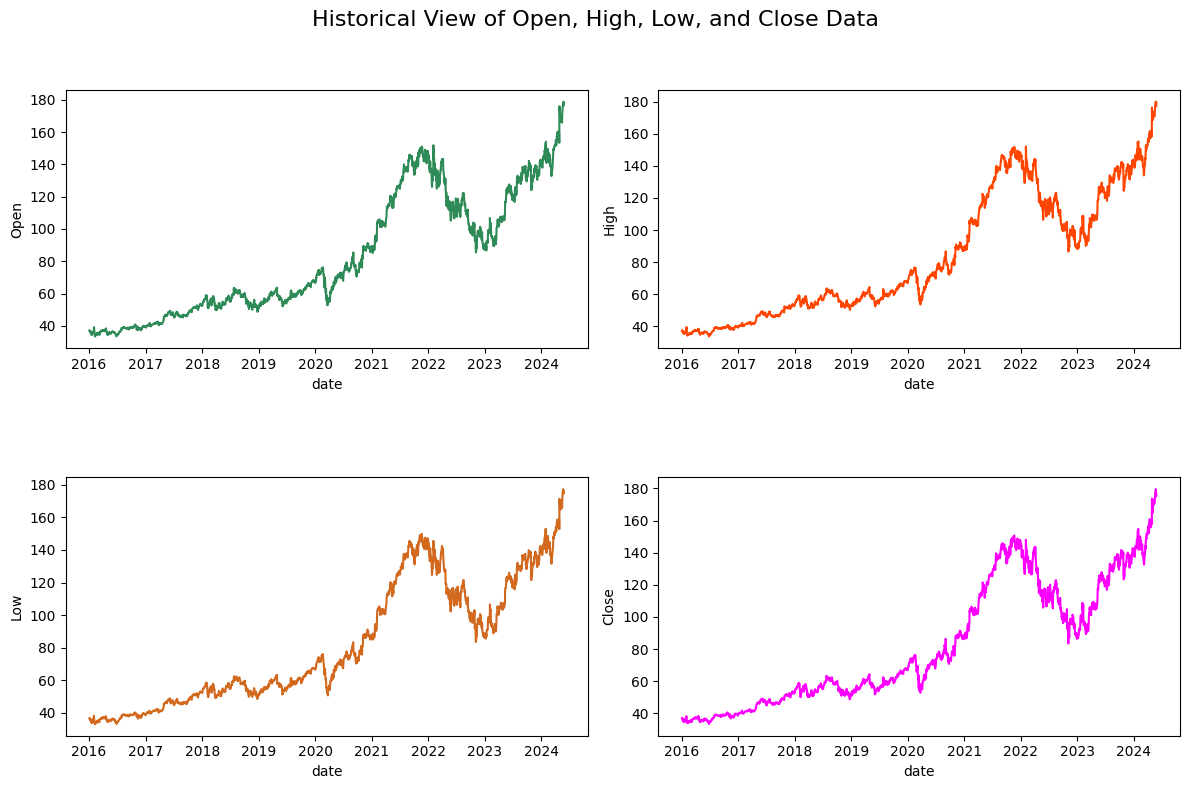

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot the data on each subplot
axs[0, 0].plot(df["date"] , df["open"], color = "seagreen")
axs[0, 1].plot(df["date"] , df["high"], color = "orangered")
axs[1, 0].plot(df["date"] , df["low"], color = "chocolate")
axs[1, 1].plot(df["date"] , df["close"], color = "fuchsia")


# Set the labels for each subplot
axs[0, 0].set_xlabel('date')
axs[0, 0].set_ylabel('Open')
axs[0, 1].set_xlabel('date' )
axs[0, 1].set_ylabel('High')
axs[1, 0].set_xlabel('date')
axs[1, 0].set_ylabel('Low')
axs[1, 1].set_xlabel('date')
axs[1, 1].set_ylabel('Close')

# Adjust the layout
plt.tight_layout()

fig.suptitle("Historical View of Open, High, Low, and Close Data", fontsize=16)  # Corrected Title Placement
plt.subplots_adjust(top=0.88, hspace=0.5)

plt.show()

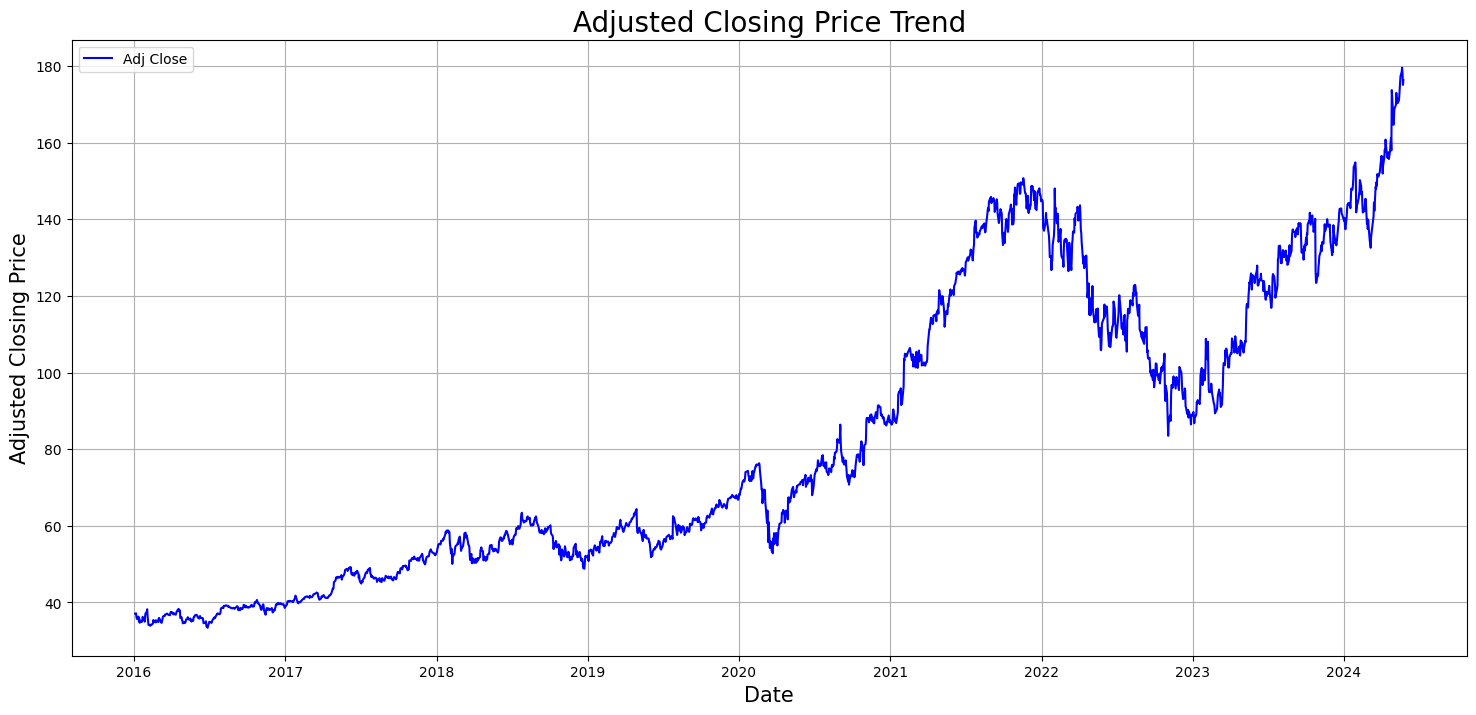

In [19]:
plt.figure(figsize= (18,8))
plt.plot(df["date"], df["adjclose"], color = "blue")
plt.title("Adjusted Closing Price Trend", fontsize = 20)
plt.xlabel("Date" , fontsize = 15)
plt.ylabel("Adjusted Closing Price", fontsize = 15)
plt.grid()
plt.legend(['Adj Close'])
plt.show()


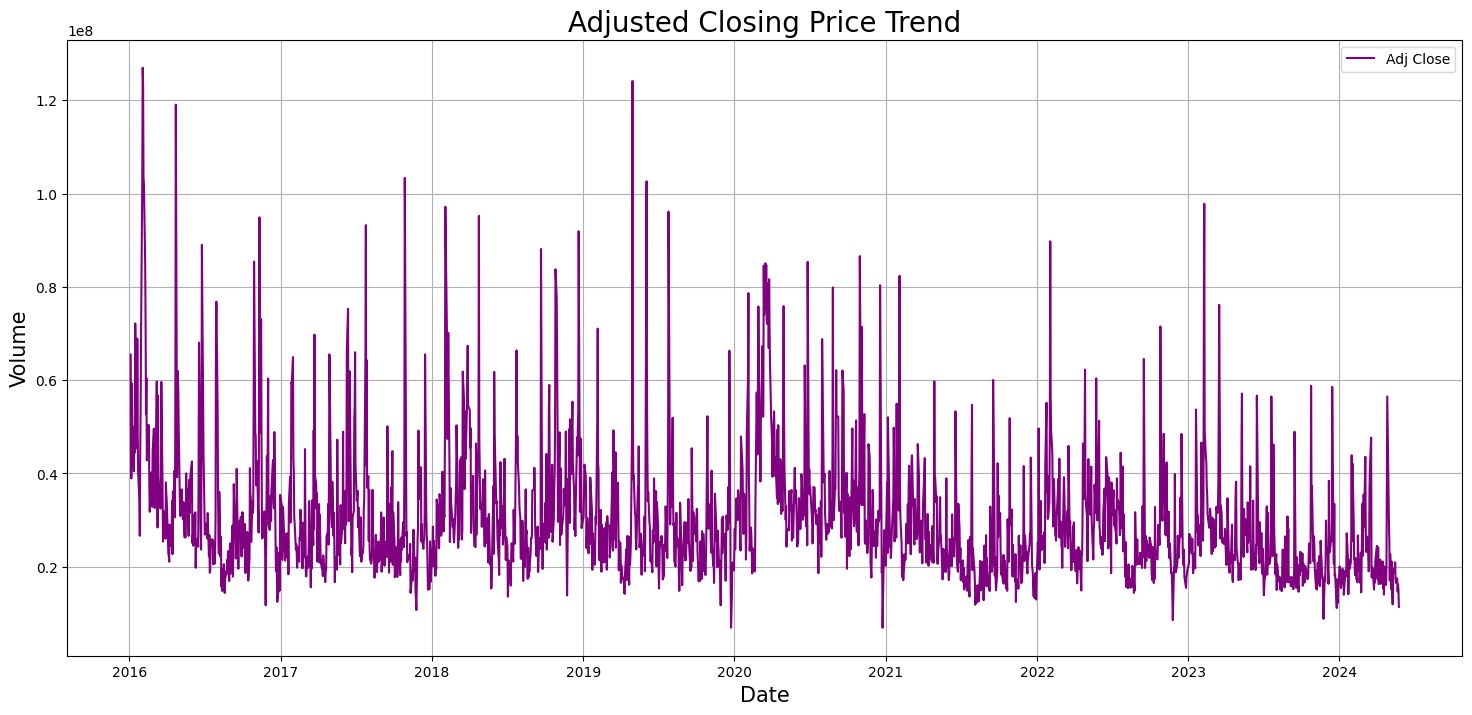

In [20]:
plt.figure(figsize= (18,8))              # figure size
plt.plot(df["date"], df["volume"], color = "purple")
plt.title("Adjusted Closing Price Trend", fontsize = 20)
plt.xlabel("Date" , fontsize = 15)
plt.ylabel("Volume", fontsize = 15)
plt.grid()
plt.legend(['Adj Close'])
plt.show()

In [21]:
df2= df.drop("date", axis = 1)

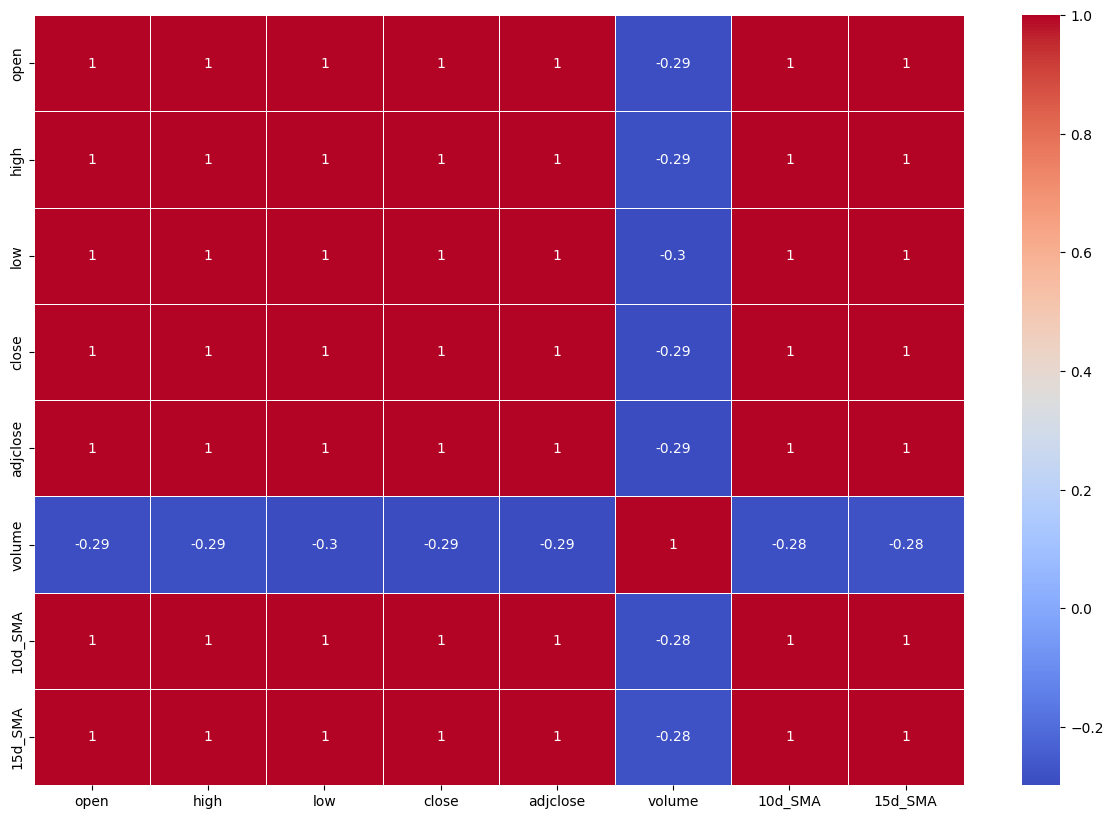

In [22]:
b,c=plt.subplots(figsize=(15,10))
sns.heatmap(df2.corr(),cmap='coolwarm',cbar=True,annot=True,linewidths=0.5,ax=c)
plt.show()

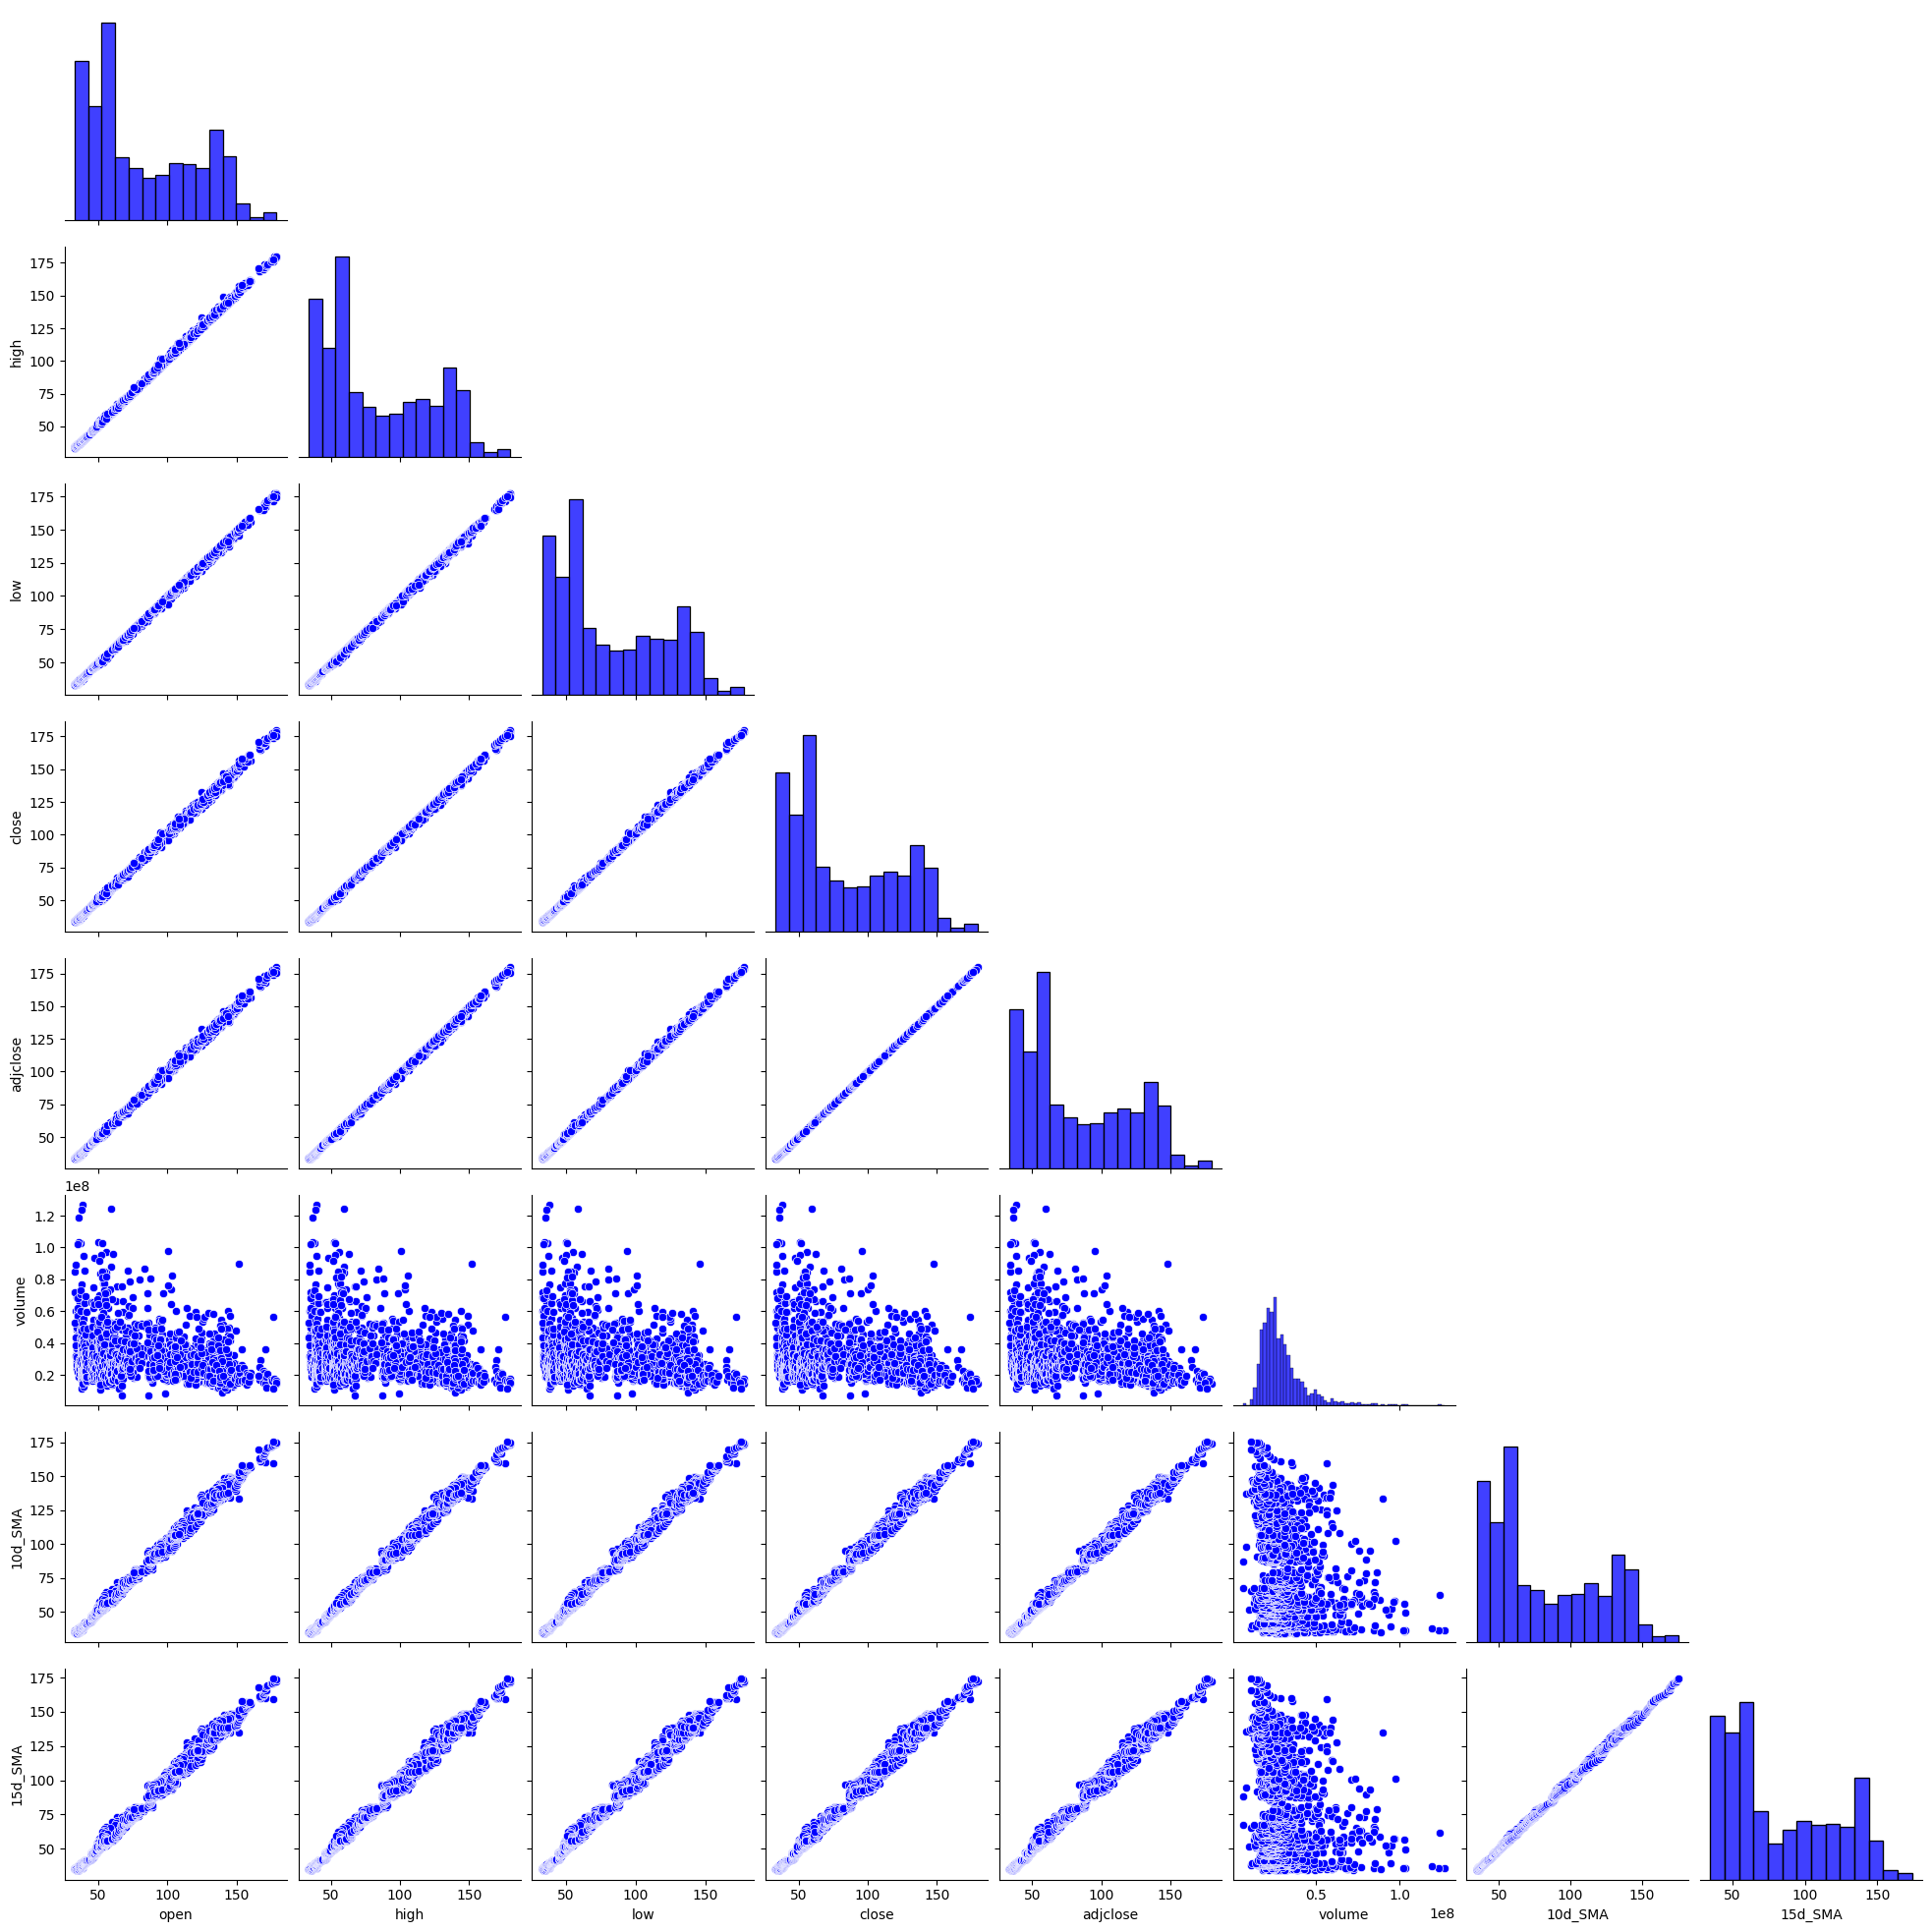

In [23]:
sns.pairplot(data=df2,
             corner=True,
             plot_kws={'color': 'blue'},  # Color for scatter plots
             diag_kws={'color': 'blue'})  # Color for diagonal histograms

# Show the plot
plt.show()

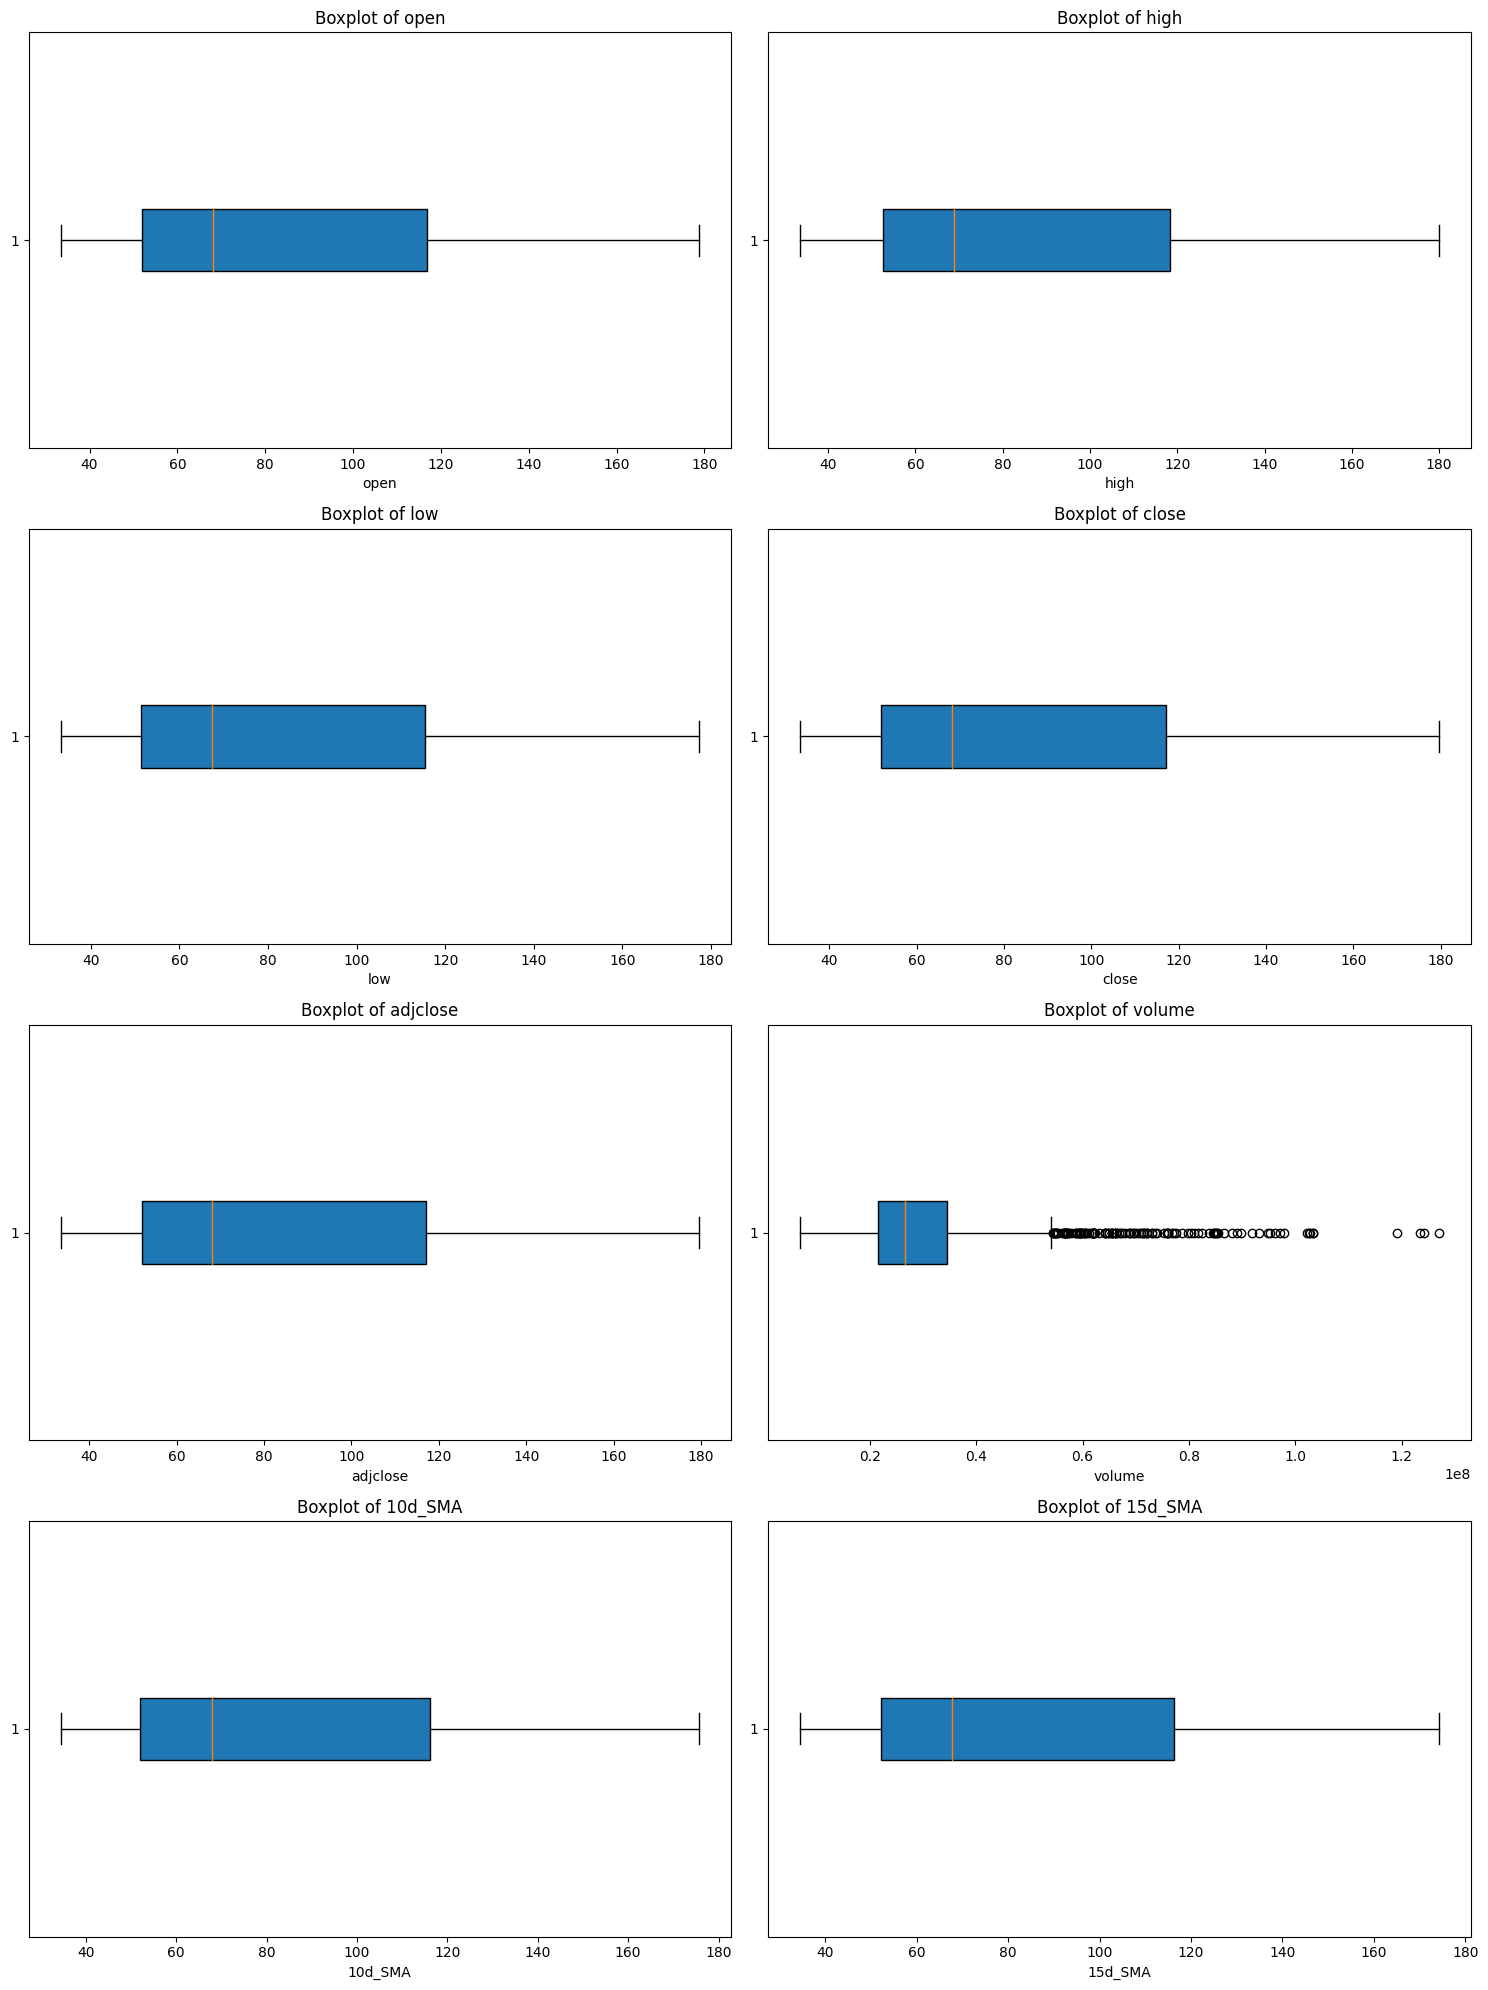

In [24]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

num_plots = 0
for col in df2.columns:

    axes[num_plots].boxplot(df2[col].dropna(), vert=False, patch_artist=True)
    axes[num_plots].set_title(f"Boxplot of {col}")
    axes[num_plots].set_xlabel(col)
    num_plots += 1

plt.tight_layout()
plt.show()


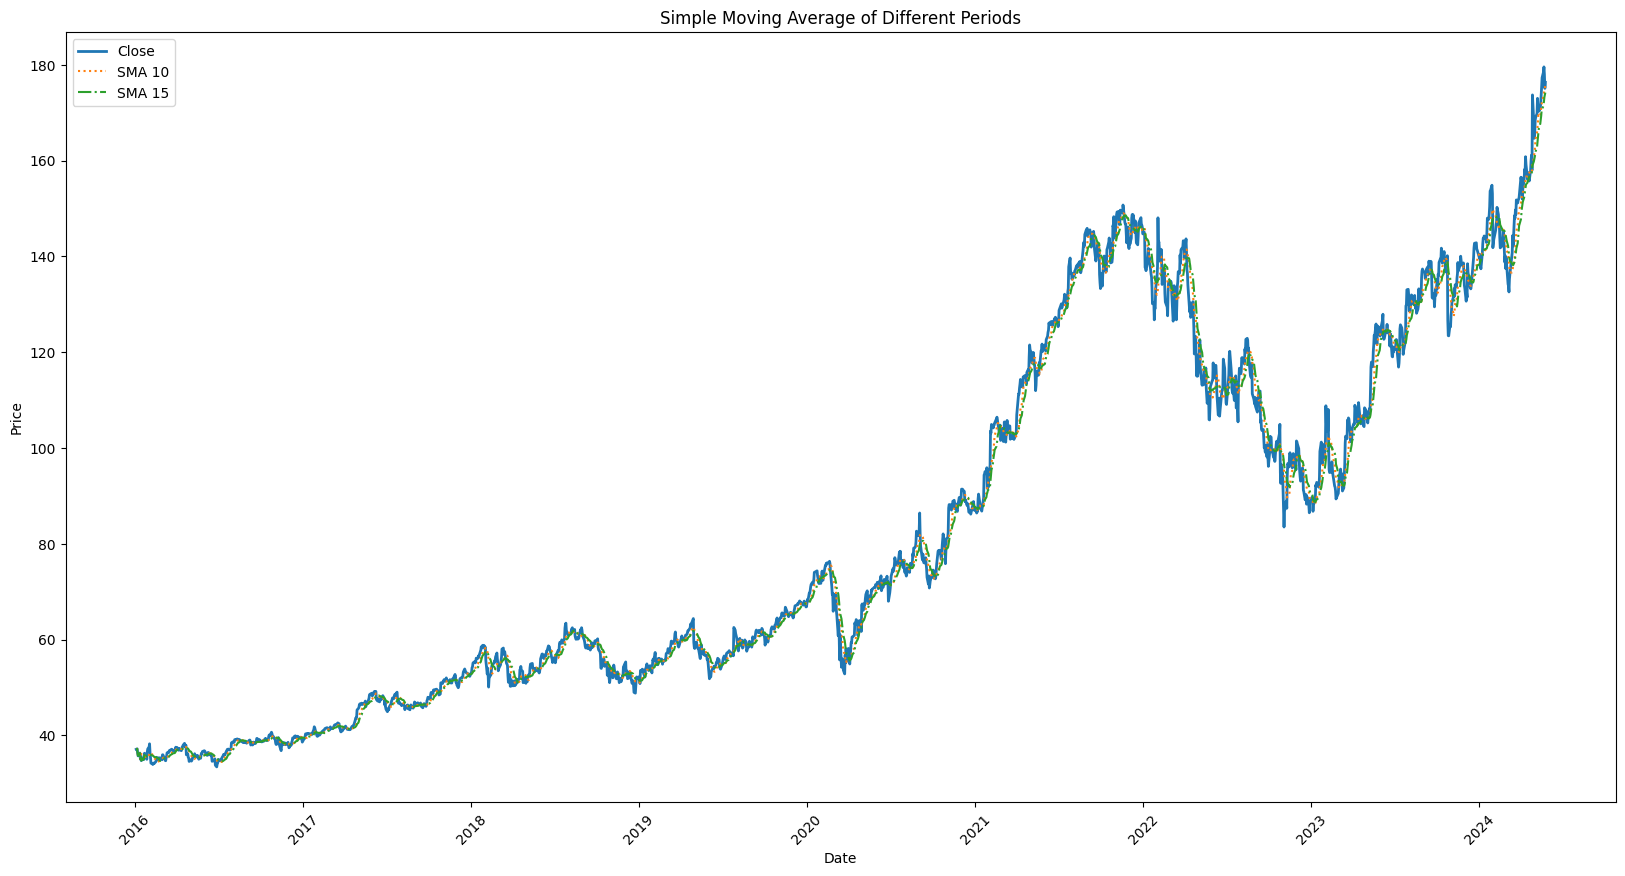

In [25]:
# Enable interactive mode
plt.ion()

plt.figure(figsize=(20, 10))
plt.plot(df['date'], df['close'], label='Close', linewidth=2)
plt.plot(df['date'], df['10d_SMA'], label='SMA 10', linestyle='dotted')
plt.plot(df['date'], df['15d_SMA'], label='SMA 15', linestyle='dashdot')

plt.title('Simple Moving Average of Different Periods')
plt.ylabel('Price')
plt.xlabel('Date')
plt.legend(loc='upper left')

# Format the X-axis to display only years
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())  # Major ticks per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Show only the year
plt.xticks(rotation=45)

plt.show()

# double click to zoom in

In [26]:
import plotly.express as px

# Create interactive plot
fig = px.line(df, x='date', y=['close', '10d_SMA', '15d_SMA'],
              labels={'value': 'Price', 'variable': 'Legend'},
              title="Simple Moving Average of Different Periods")

# Enable zooming
fig.update_layout(xaxis=dict(rangeslider=dict(visible=True), type="date"))

# Show interactive plot
fig.show()

In [27]:
d_change = df['close'].diff()
fig = px.histogram(d_change, nbins=50, title='Daily Price Changes Histogram Plot ')
fig.update_xaxes(title='Daily Price Change')
fig.update_yaxes(title='Frequency')
#fig.update_layout(template='plotly_dark')
fig.show()

In [28]:
df3 = df2[['open', 'high', 'low', 'volume', 'close']]
df3

,open,high,low,volume,close
0,37.150002,37.202999,36.562901,65456000,37.091999
1,37.322498,37.599998,36.931999,39014000,37.129002
2,36.500000,37.359001,36.445999,38940000,37.181000
3,36.515499,36.924999,35.952999,59274000,36.319500
4,36.572498,36.661499,35.650002,49018000,35.723499
...,...,...,...,...,...
2108,177.309998,179.949997,177.225006,17495100,178.460007
2109,178.399994,179.820007,177.309998,14706000,179.539993
2110,178.399994,178.852005,176.779999,16189400,178.000000
2111,178.779999,179.910004,174.539993,14928400,175.059998


# 7. Data Normalization

In [29]:
scaler = MinMaxScaler(feature_range=(-1, 1))
df3['open'] = scaler.fit_transform(df3.open.values.reshape(-1, 1))
df3['high'] = scaler.fit_transform(df3.high.values.reshape(-1, 1))
df3['low'] = scaler.fit_transform(df3.low.values.reshape(-1, 1))
df3['close'] = scaler.fit_transform(df3.close.values.reshape(-1, 1))
df3['volume'] = scaler.fit_transform(df3.volume.values.reshape(-1, 1))

df4 = pd.DataFrame(df3)

# 8. Modeling

# 9. Tensorflow

### Preparing Data for Time Series

In [30]:
seq_len = 10
sequence = []
for index in range(len(df4) - seq_len + 1):
    sequence.append(df4[index: index + seq_len])
sequence = np.array(sequence)
print(sequence.shape)

(2104, 10, 5)


In [31]:
train=int(len(sequence)*0.8)
val = int(len(sequence)*0.1)
test = len(sequence) - train - val

In [32]:
train_data = sequence[:train]
val_data = sequence[train:train + val]
test_data = sequence[train + val:]

In [33]:
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (1683, 10, 5)
Validation shape: (210, 10, 5)
Test shape: (211, 10, 5)


In [34]:
# Splitting into X (features) and y (target)
X_train, y_train = train_data[:, :, :-1], train_data[:, -1, -1]  # Use last 'close' as target
X_val, y_val = val_data[:, :, :-1], val_data[:, -1, -1]
X_test, y_test = test_data[:, :, :-1], test_data[:, -1, -1]

In [35]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1683, 10, 4)
y_train shape: (1683,)
X_val shape: (210, 10, 4)
y_val shape: (210,)
X_test shape: (211, 10, 4)
y_test shape: (211,)


## 9.1. LSTM

In [36]:
seq_len = X_train.shape[1]  # Number of time steps
num_features = X_train.shape[2]

model = Sequential()
# First LSTM layer
model.add(LSTM(128, return_sequences=True, input_shape=(seq_len, num_features)))
model.add(Dropout(0.2))  # Regularization

# Second LSTM layer (return_sequences=False for last layer)
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))

# Dense layer
model.add(Dense(32, activation="relu"))
model.add(Dense(1))  # Output layer for regression (predicting stock price)

# Model summary
model.summary()

2025-04-13 03:28:38.494345: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 128)             │          68,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119,617 (467.25 KB)

 Trainable params: 119,617 (467.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [38]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                       validation_data=(X_val, y_val))

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.1212 - val_loss: 0.0040
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0069 - val_loss: 0.0032
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0054 - val_loss: 0.0029
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0041 - val_loss: 0.0028
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0036 - val_loss: 0.0028
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0033 - val_loss: 0.0026
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0033 - val_loss: 0.0026
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

In [39]:
model.history.history.keys()

dict_keys(['loss', 'val_loss'])

In [40]:
df_his = pd.DataFrame(history.history)
df_his

,loss,val_loss
0,0.046934,0.003977
1,0.006162,0.003245
2,0.005222,0.002940
3,0.004015,0.002797
4,0.003751,0.002820
5,0.003485,0.002929
6,0.003444,0.002627
7,0.003297,0.002804
8,0.002976,0.002584
9,0.002988,0.002610


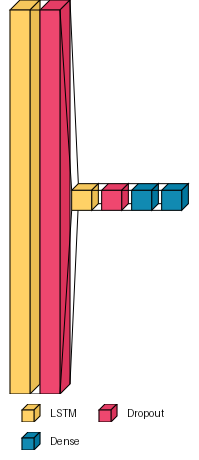

In [41]:
visualkeras.layered_view(model, scale_xy=3, legend=True)

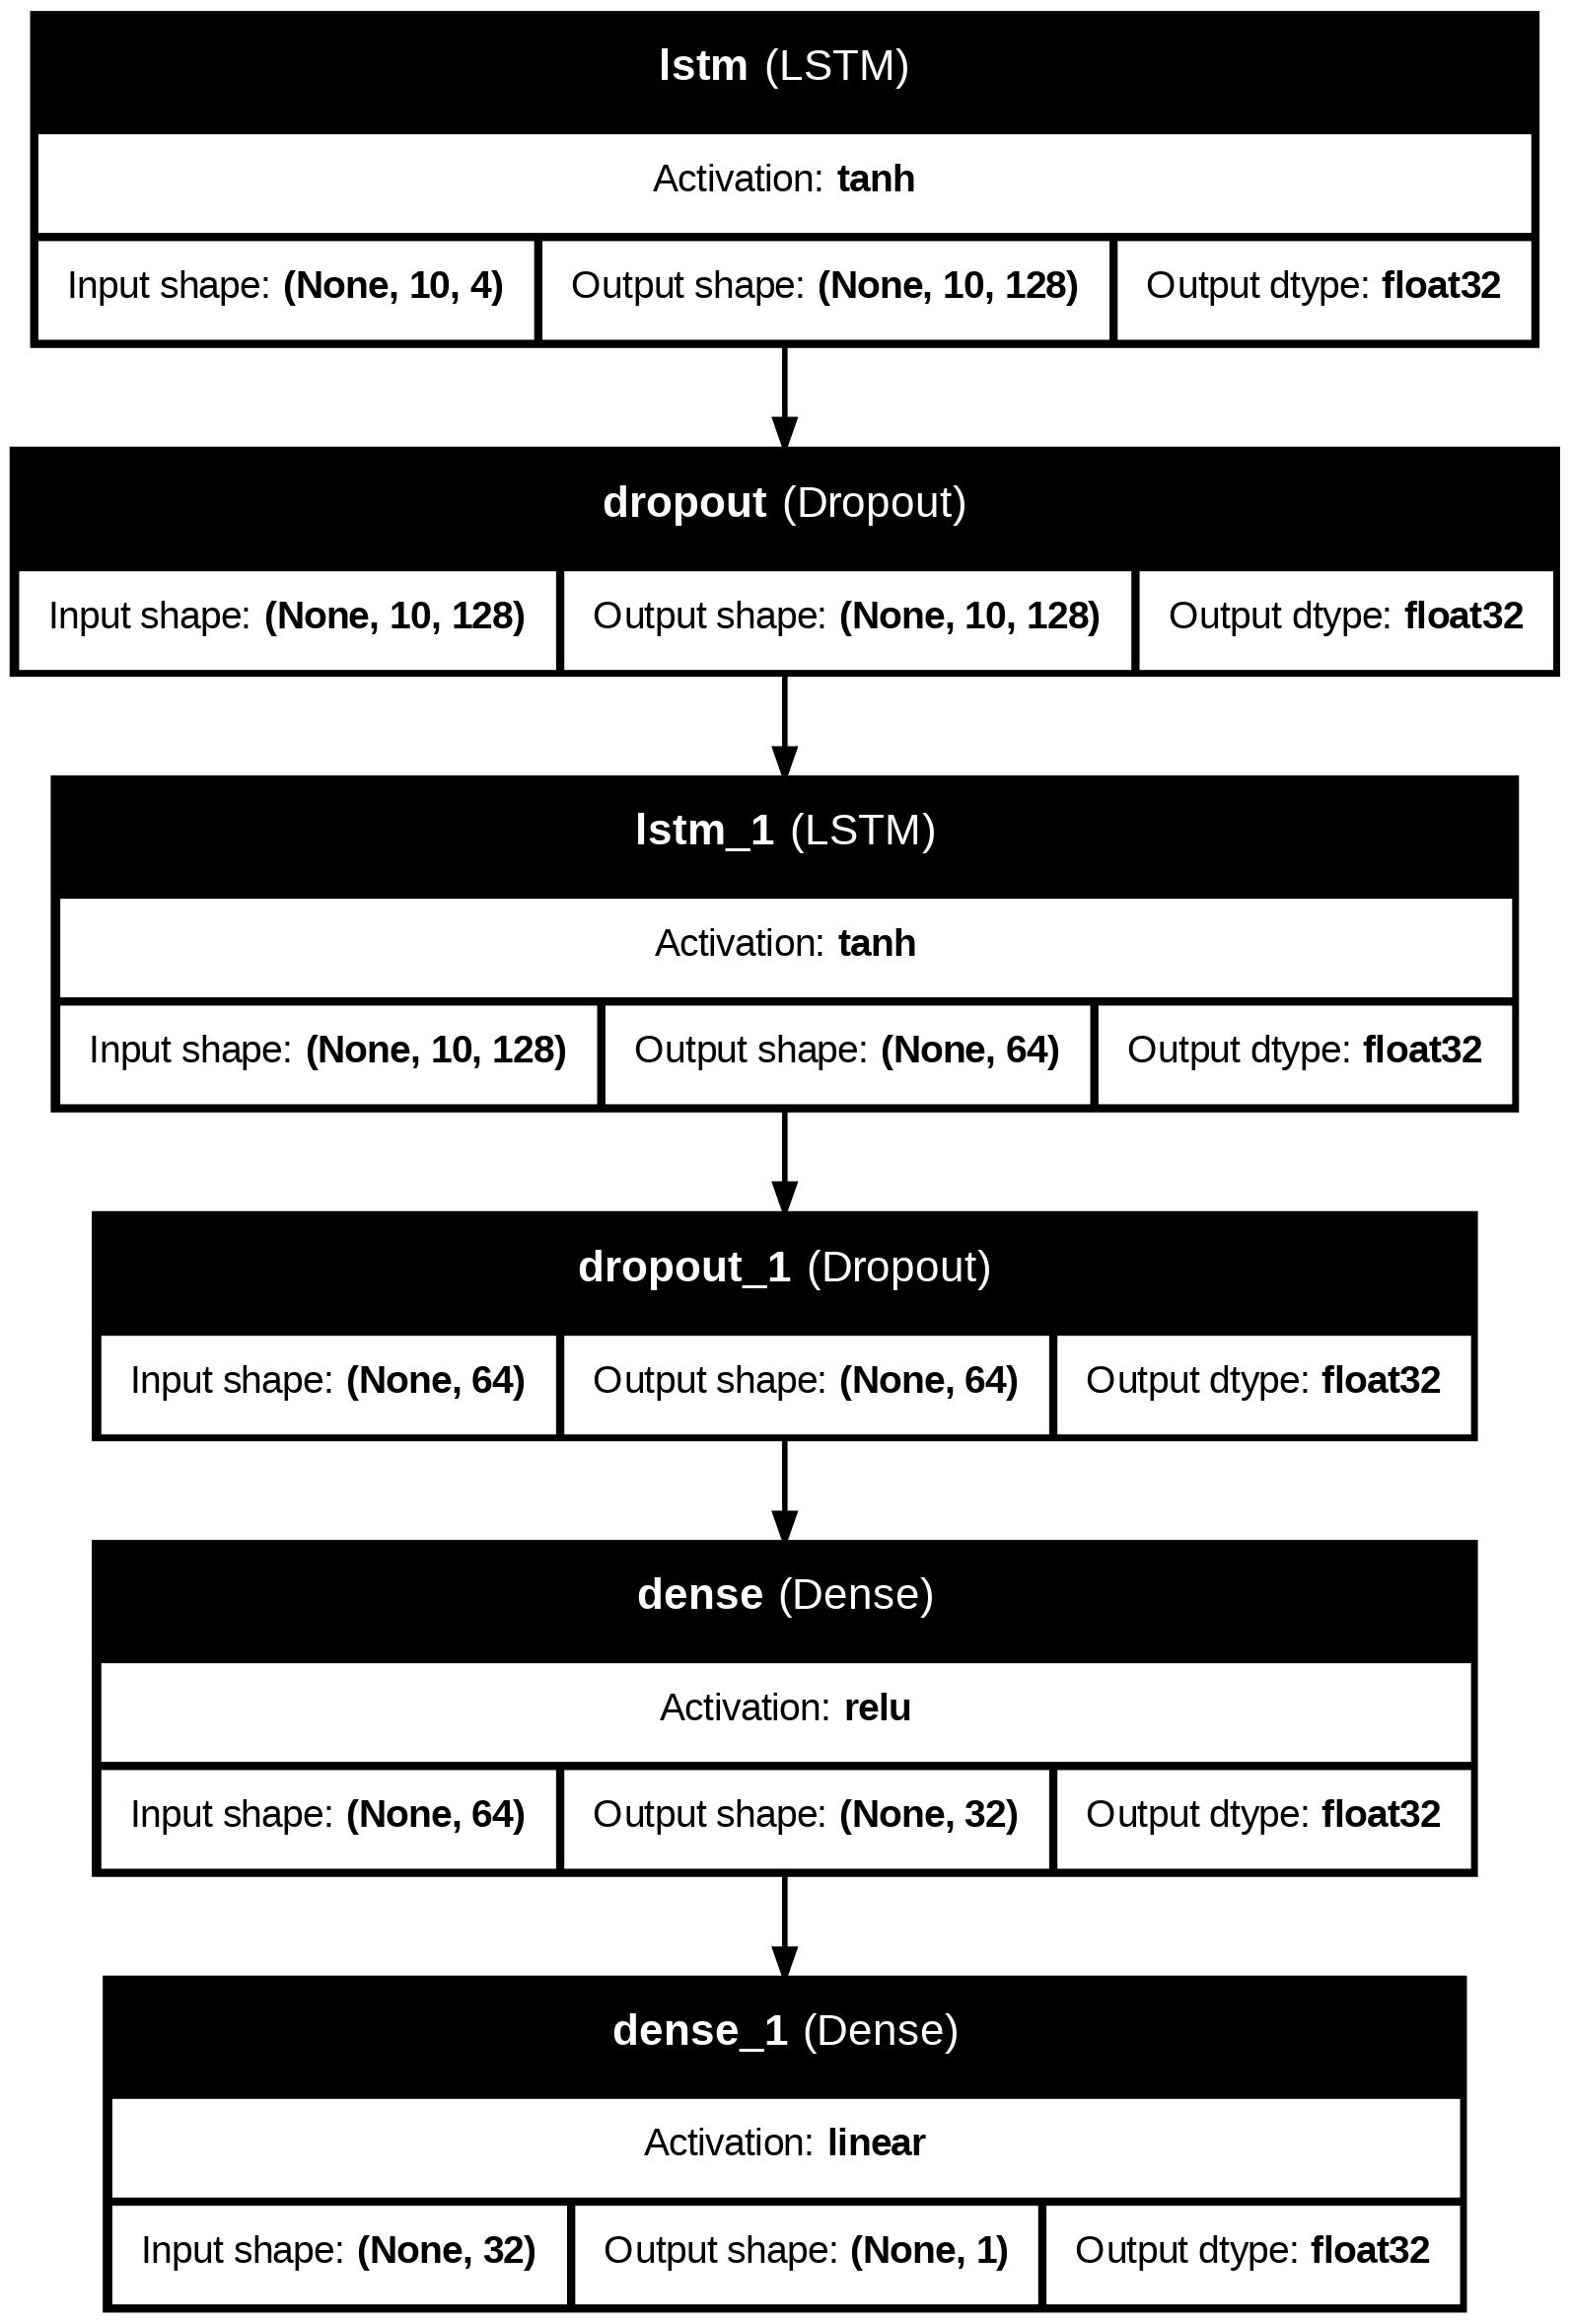

In [42]:
tf.keras.utils.plot_model(
    model,
    to_file='model1.png',
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=200,
    show_layer_activations=True,
    )

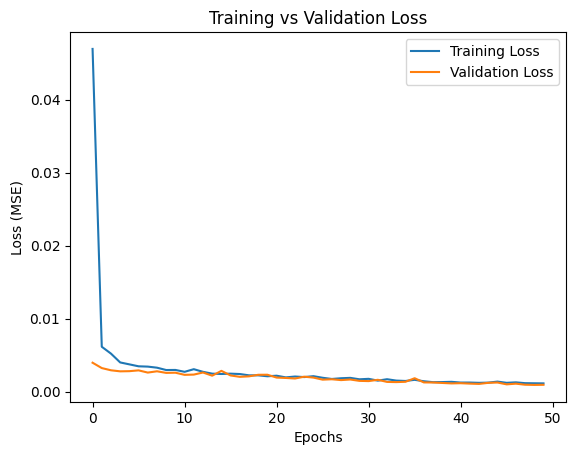

In [43]:
#import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [44]:
test_loss = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011     
Test Loss: 0.001643748371861875


In [45]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


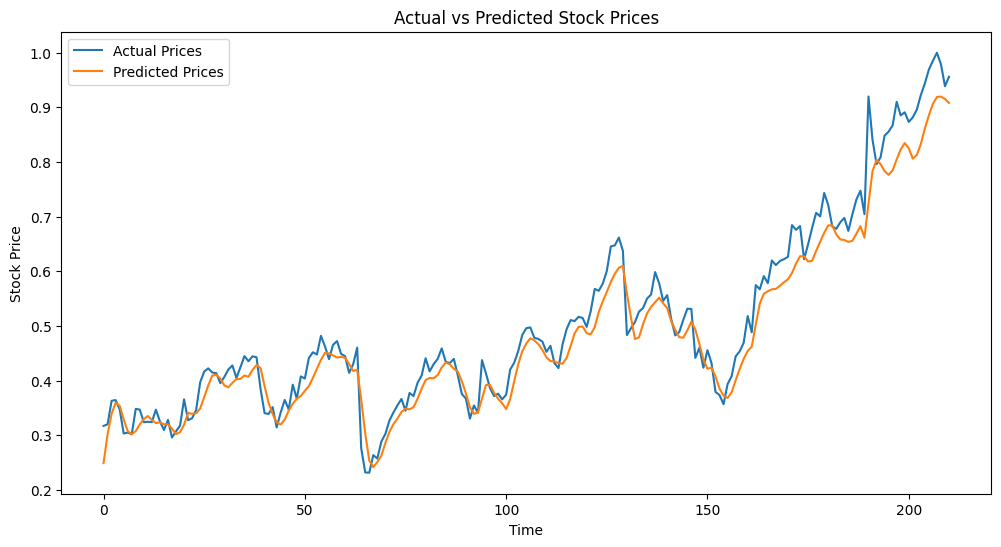

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Prices')
plt.plot(y_pred, label='Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.title('Actual vs Predicted Stock Prices')
plt.show()

## 8.1.1. Prediction

In [47]:
# Predicting the next 10 days
latest_prediction = []
last_seq = X_test[:-1]

for _ in range(10):
    prediction = model.predict(last_seq)
    latest_prediction.append(prediction)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [48]:
predicted_data_next = np.array(latest_prediction).reshape(-1, 5)
last_date = df['date'].max()
next_10_days = [last_date + timedelta(days=i) for i in range(1, 11)]

# Iterate over all features
for i, feature_name in enumerate(['Open', 'High', 'Low', 'Volume', 'Close']):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=next_10_days,
        y=predicted_data_next[:, i],
        mode='lines+markers',
        name=f'Predicted {feature_name.capitalize()} Prices',
        #line=dict(color='#f4a261'),
        #marker=dict(color='#f4a261')
    ))

    fig.update_layout(
        title=f'Predicted {feature_name} Prices for the Next 10 Days',
        xaxis_title='Date',
        yaxis_title=f'{feature_name} Price',
        plot_bgcolor='Black'
    )

    fig.show()

# 10. PyTorch

In [49]:
df_ten = df[['open','high','low', 'volume','close','10d_SMA']].copy(deep=True)
df_fifteen = df[['open','high','low', 'volume','close','15d_SMA']].copy(deep=True)
df_all = df[['open','high','low', 'volume','close','10d_SMA','15d_SMA']].copy(deep=True)

In [50]:
scaler = MinMaxScaler(feature_range=(0,1)).fit(df_ten.low.values.reshape(-1,1))
df_ten['open'] = scaler.transform(df_ten.open.values.reshape(-1,1))
df_ten['high'] = scaler.transform(df_ten.high.values.reshape(-1,1))
df_ten['low'] = scaler.transform(df_ten.low.values.reshape(-1,1))
df_ten['close'] = scaler.transform(df_ten.close.values.reshape(-1,1))
df_ten['volume'] = scaler.transform(df_ten.volume.values.reshape(-1,1))
df_ten['10d_SMA'] = scaler.transform(df_ten['10d_SMA'].values.reshape(-1,1))


scaler = MinMaxScaler(feature_range=(0,1)).fit(df_fifteen.low.values.reshape(-1,1))
df_fifteen['open'] = scaler.transform(df_fifteen.open.values.reshape(-1,1))
df_fifteen['high'] = scaler.transform(df_fifteen.high.values.reshape(-1,1))
df_fifteen['low'] = scaler.transform(df_fifteen.low.values.reshape(-1,1))
df_fifteen['close'] = scaler.transform(df_fifteen.close.values.reshape(-1,1))
df_fifteen['volume'] = scaler.transform(df_fifteen.volume.values.reshape(-1,1))
df_fifteen['15d_SMA'] = scaler.transform(df_fifteen['15d_SMA'].values.reshape(-1,1))


scaler = MinMaxScaler(feature_range=(0,1)).fit(df_all.low.values.reshape(-1,1))
df_all['open'] = scaler.transform(df_all.open.values.reshape(-1,1))
df_all['high'] = scaler.transform(df_all.high.values.reshape(-1,1))
df_all['low'] = scaler.transform(df_all.low.values.reshape(-1,1))
df_all['close'] = scaler.transform(df_all.close.values.reshape(-1,1))
df_all['volume'] = scaler.transform(df_all.volume.values.reshape(-1,1))
df_all['10d_SMA'] = scaler.transform(df_all['10d_SMA'].values.reshape(-1,1))
df_all['15d_SMA'] = scaler.transform(df_all['15d_SMA'].values.reshape(-1,1))

In [51]:
data_10d = df_ten[['open','high','low', 'volume','close','10d_SMA']].values
data_15d = df_fifteen[['open','high','low', 'volume','close','15d_SMA']].values
data_all = df_all[['open','high','low', 'volume','close','10d_SMA','15d_SMA']].values

In [52]:
print(data_10d.shape)
print(data_15d.shape)
print(data_all.shape)

(2113, 6)
(2113, 6)
(2113, 7)


In [53]:
seq_len = 10
sequence_10days = []
for index in range(len(data_10d) - seq_len + 1):
    sequence_10days.append(data_10d[index: index + seq_len])
sequence_10days = np.array(sequence_10days)
print(sequence_10days.shape)


seq_len = 15
sequence_15days = []
for index in range(len(data_15d) - seq_len + 1):
    sequence_15days.append(data_15d[index: index + seq_len])
sequence_15days = np.array(sequence_15days)
print(sequence_15days.shape)

sequence_all=[]
for index in range(len(data_all) - seq_len + 1):
    sequence_all.append(data_all[index: index + seq_len])
sequence_all = np.array(sequence_all)
print(sequence_all.shape)

(2104, 10, 6)
(2099, 15, 6)
(2099, 15, 7)


In [54]:
train_10_len = int(len(sequence_10days)*0.8)
val_10_len = int(len(sequence_10days)*0.1)
test_10_len = len(sequence_10days) - train_10_len - val_10_len

train_15_len = int(len(sequence_15days)*0.8)
val_15_len = int(len(sequence_15days)*0.1)
test_15_len = len(sequence_15days) - train_15_len - val_15_len

train_all_len = int(len(sequence_all)*0.8)
val_all_len = int(len(sequence_all)*0.1)
test_all_len = len(sequence_all) - train_all_len - val_all_len

In [55]:
train_data_10days = sequence_10days[:train_10_len]
val_data_10days = sequence_10days[train_10_len:train_10_len + val_10_len]
test_data_10days = sequence_10days[train_10_len + val_10_len:]

train_data_15days = sequence_15days[:train_15_len]
val_data_15days = sequence_15days[train_15_len:train_15_len + val_15_len]
test_data_15days = sequence_15days[train_15_len + val_15_len:]

train_data_all = sequence_all[:train_all_len]
val_data_all = sequence_all[train_all_len:train_all_len + val_all_len]
test_data_all = sequence_all[train_all_len + val_all_len:]

In [56]:
print("Train shape_10days:", train_data_10days.shape)
print("Validation shape_10days:", val_data_10days.shape)
print("Test shape_10days:", test_data_10days.shape)
print()
print("Train shape_15days:", train_data_15days.shape)
print("Validation shape_15days:", val_data_15days.shape)
print("Test shape_15days:", test_data_15days.shape)
print()
print("Train shape_all:", train_data_all.shape)
print("Validation shape_all:", val_data_all.shape)
print("Test shape_all:", test_data_all.shape)

Train shape_10days: (1683, 10, 6)
Validation shape_10days: (210, 10, 6)
Test shape_10days: (211, 10, 6)

Train shape_15days: (1679, 15, 6)
Validation shape_15days: (209, 15, 6)
Test shape_15days: (211, 15, 6)

Train shape_all: (1679, 15, 7)
Validation shape_all: (209, 15, 7)
Test shape_all: (211, 15, 7)


In [57]:
# Splitting into X (features) and y (target)
X_train_10, y_train_10 = train_data_10days[:, :, :-1], train_data_10days[:, -1, -1]
X_val_10, y_val_10 = val_data_10days[:, :, :-1], val_data_10days[:, -1, -1]
X_test_10, y_test_10 = test_data_10days[:, :, :-1], test_data_10days[:, -1, -1]

X_train_15, y_train_15 = train_data_15days[:, :, :-1], train_data_15days[:, -1, -1]
X_val_15, y_val_15 = val_data_15days[:, :, :-1], val_data_15days[:, -1, -1]
X_test_15, y_test_15 = test_data_15days[:, :, :-1], test_data_15days[:, -1, -1]

X_train_all, y_train_all = train_data_all[:, :, :-1], train_data_all[:, -1, -1]
X_val_all, y_val_all = val_data_all[:, :, :-1], val_data_all[:, -1, -1]
X_test_all, y_test_all = test_data_all[:, :, :-1], test_data_all[:, -1, -1]

In [58]:
print("SMA10 train, validation and test shape:")
print("X_train_10:", X_train_10.shape)
print("y_train_10:", y_train_10.shape)

print("X_val_10:", X_val_10.shape)
print("y_val_10:", y_val_10.shape)

print("X_test_10:", X_test_10.shape)
print("y_test_10:", y_test_10.shape)

print()

print("SMA15 train, validation and test shape:")
print("X_train_15:", X_train_15.shape)
print("y_train_10:", y_train_15.shape)

print("X_val_15:", X_val_15.shape)
print("y_val_15:", y_val_15.shape)

print("X_test_15:", X_test_15.shape)
print("y_test_15:", y_test_15.shape)

print()

print("All train, validation and test shape:")
print("X_train_all:", X_train_all.shape)
print("y_train_all:", y_train_all.shape)

print("X_val_all:", X_val_all.shape)
print("y_val_all:", y_val_all.shape)

print("X_test_all:", X_test_all.shape)
print("y_test_all:", y_test_all.shape)

SMA10 train, validation and test shape:
X_train_10: (1683, 10, 5)
y_train_10: (1683,)
X_val_10: (210, 10, 5)
y_val_10: (210,)
X_test_10: (211, 10, 5)
y_test_10: (211,)

SMA15 train, validation and test shape:
X_train_15: (1679, 15, 5)
y_train_10: (1679,)
X_val_15: (209, 15, 5)
y_val_15: (209,)
X_test_15: (211, 15, 5)
y_test_15: (211,)

All train, validation and test shape:
X_train_all: (1679, 15, 6)
y_train_all: (1679,)
X_val_all: (209, 15, 6)
y_val_all: (209,)
X_test_all: (211, 15, 6)
y_test_all: (211,)


In [59]:
# Torch.Tensor / Dataloader
# Transform them into tensors

X_train_10 = torch.tensor(X_train_10).float()
y_train_10 = torch.tensor(y_train_10).float()
X_val_10 = torch.tensor(X_val_10).float()
y_val_10 = torch.tensor(y_val_10).float()
train_set_10 = TensorDataset(X_train_10,y_train_10)
train_dataloader_10 = DataLoader(train_set_10, batch_size=32, shuffle=False)
val_set_10 = TensorDataset(X_val_10 ,y_val_10)
val_dataloader_10 = DataLoader(val_set_10, batch_size=32, shuffle=False)


X_train_15 = torch.tensor(X_train_15).float()
y_train_15 = torch.tensor(y_train_15).float()
X_val_15 = torch.tensor(X_val_15).float()
y_val_15 = torch.tensor(y_val_15).float()
train_set_15 = TensorDataset(X_train_15,y_train_15)
train_dataloader_15 = DataLoader(train_set_15, batch_size=32, shuffle=False)
val_set_15 = TensorDataset(X_val_15 ,y_val_15)
val_dataloader_15 = DataLoader(val_set_15, batch_size=32, shuffle=False)


X_train_all = torch.tensor(X_train_all).float()
y_train_all = torch.tensor(y_train_all).float()
X_val_all = torch.tensor(X_val_all).float()
y_val_all = torch.tensor(y_val_all).float()
train_set_all = TensorDataset(X_train_all,y_train_all)
train_dataloader_all = DataLoader(train_set_all, batch_size=32, shuffle=False)
val_set_all = TensorDataset(X_val_all ,y_val_all)
val_dataloader_all = DataLoader(val_set_all, batch_size=32, shuffle=False)

# 10.1. LSTM

In [60]:
def preprocess_data(df, features, target_features, seq_len=10, split_ratio=(0.8, 0.1, 0.1)):
    data = df[features].copy(deep=True)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    data[features] = scaler.fit_transform(data[features])

    sequence_data = []
    target_data = []
    for i in range(len(data) - seq_len):
        sequence = data.iloc[i:i + seq_len].values
        targets = data.iloc[i + seq_len][target_features].values  # prediction at t+1
        sequence_data.append(sequence)
        target_data.append(targets)

    sequence_data = np.array(sequence_data)
    target_data = np.array(target_data)

    total = len(sequence_data)
    train_end = int(total * split_ratio[0])
    val_end = train_end + int(total * split_ratio[1])

    X_train, y_train = sequence_data[:train_end], target_data[:train_end]
    X_val, y_val = sequence_data[train_end:val_end], target_data[train_end:val_end]
    X_test, y_test = sequence_data[val_end:], target_data[val_end:]

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler


In [61]:
class GoogleStockLSTM(nn.Module):
    def __init__(self, num_features, output_size):
        super(GoogleStockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        return self.fc(last_out)


In [62]:
def train_lstm_model(train_loader, val_loader, num_features, output_size, epochs=50):
    model = GoogleStockLSTM(num_features, output_size)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item() * X_batch.size(0)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {total_loss / len(train_loader.dataset):.4f} | Val Loss: {val_loss / len(val_loader.dataset):.4f}")

    return model


In [63]:
def predict_and_plot(model, X_test, y_test, scaler, target_features, feature_names):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).numpy()

    y_test_np = y_test.numpy()

    # Inverse transform
    dummy = np.zeros((len(predictions), len(feature_names)))
    pred_inv = []
    test_inv = []

    for i, feature in enumerate(target_features):
        idx = feature_names.index(feature)
        dummy[:, :] = 0
        dummy[:, idx] = predictions[:, i]
        pred_inv.append(scaler.inverse_transform(dummy)[:, idx])

        dummy[:, idx] = y_test_np[:, i]
        test_inv.append(scaler.inverse_transform(dummy)[:, idx])

    # Plot each feature
    plt.figure(figsize=(14, 8))
    for i, feature in enumerate(target_features):
        plt.plot(test_inv[i], label=f'Actual {feature}')
        plt.plot(pred_inv[i], label=f'Predicted {feature}')
    plt.title('Actual vs Predicted (Multi-feature)')
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [64]:
def predict_and_plot(model, X_test, y_test, scaler, target_features, feature_names):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).numpy()

    y_test_np = y_test.numpy()

    # Create empty arrays for inverse transforming predictions and actuals
    dummy_pred = np.zeros((len(predictions), len(feature_names)))
    dummy_actual = np.zeros((len(predictions), len(feature_names)))

    for i, feature in enumerate(target_features):
        idx = feature_names.index(feature)
        dummy_pred[:, idx] = predictions[:, i]
        dummy_actual[:, idx] = y_test_np[:, i]

    inv_pred = scaler.inverse_transform(dummy_pred)
    inv_actual = scaler.inverse_transform(dummy_actual)

    # Plot each feature separately
    plt.figure(figsize=(15, 30))
    for i, feature in enumerate(target_features):
        plt.subplot(len(target_features), 1, i + 1)
        plt.plot(inv_actual[:, feature_names.index(feature)], label='Actual')
        plt.plot(inv_pred[:, feature_names.index(feature)], label='Predicted')
        plt.title(f'{feature.capitalize()} - Actual vs Predicted')
        plt.xlabel('Time')
        plt.ylabel(feature.capitalize())
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()


Epoch 1/50 | Train Loss: 0.1156 | Val Loss: 0.0037
Epoch 2/50 | Train Loss: 0.0031 | Val Loss: 0.0052
Epoch 3/50 | Train Loss: 0.0020 | Val Loss: 0.0042
Epoch 4/50 | Train Loss: 0.0015 | Val Loss: 0.0035
Epoch 5/50 | Train Loss: 0.0013 | Val Loss: 0.0029
Epoch 6/50 | Train Loss: 0.0012 | Val Loss: 0.0028
Epoch 7/50 | Train Loss: 0.0011 | Val Loss: 0.0027
Epoch 8/50 | Train Loss: 0.0010 | Val Loss: 0.0027
Epoch 9/50 | Train Loss: 0.0010 | Val Loss: 0.0025
Epoch 10/50 | Train Loss: 0.0010 | Val Loss: 0.0024
Epoch 11/50 | Train Loss: 0.0009 | Val Loss: 0.0024
Epoch 12/50 | Train Loss: 0.0009 | Val Loss: 0.0023
Epoch 13/50 | Train Loss: 0.0009 | Val Loss: 0.0023
Epoch 14/50 | Train Loss: 0.0009 | Val Loss: 0.0022
Epoch 15/50 | Train Loss: 0.0009 | Val Loss: 0.0021
Epoch 16/50 | Train Loss: 0.0008 | Val Loss: 0.0021
Epoch 17/50 | Train Loss: 0.0008 | Val Loss: 0.0020
Epoch 18/50 | Train Loss: 0.0008 | Val Loss: 0.0019
Epoch 19/50 | Train Loss: 0.0008 | Val Loss: 0.0018
Epoch 20/50 | Train L

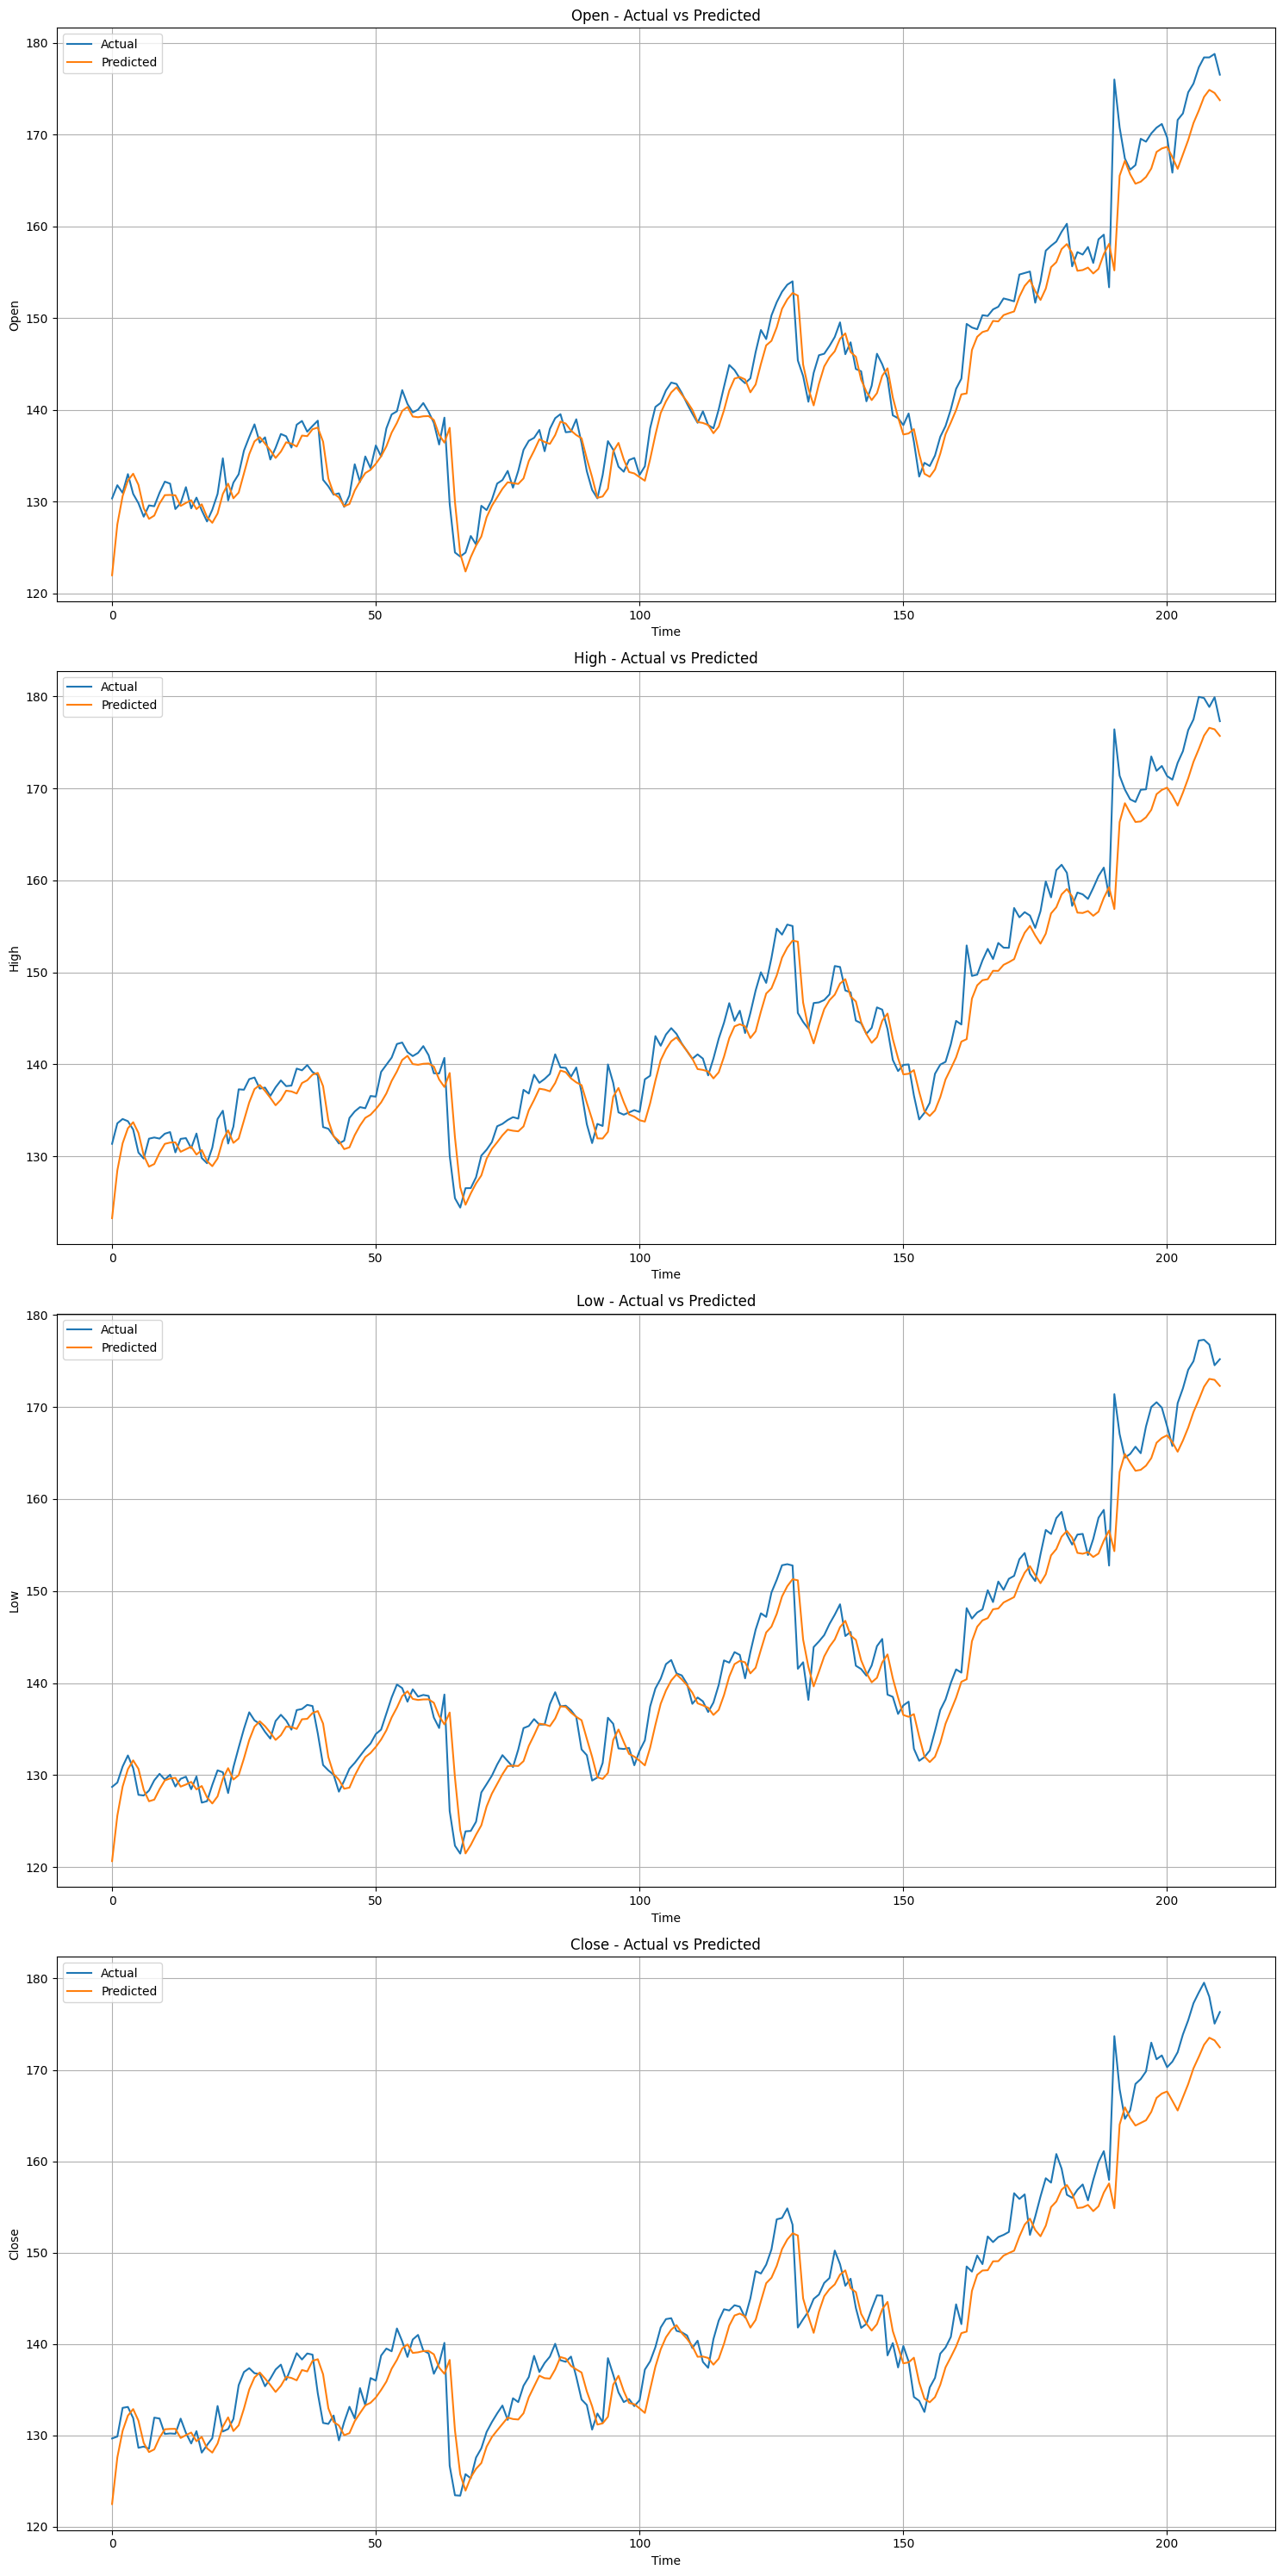

In [65]:
features = ['open', 'high', 'low', 'volume', 'close', '10d_SMA', '15d_SMA']
target_features = ['open', 'high', 'low', 'close']
seq_len = 10

X_train, y_train, X_val, y_val, X_test, y_test, scaler = preprocess_data(df, features, target_features, seq_len)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

model = train_lstm_model(train_loader, val_loader, num_features=len(features), output_size=len(target_features))

predict_and_plot(model, X_test, y_test, scaler, target_features, features)


In [66]:
def forecast_next_days(model, last_sequence, scaler, feature_names, target_features, days=10):
    model.eval()
    predictions = []

    current_seq = last_sequence.clone().unsqueeze(0)  # shape: (1, seq_len, features)

    for _ in range(days):
        with torch.no_grad():
            pred = model(current_seq).squeeze(0).numpy()

        # Create dummy input to inverse transform
        dummy = np.zeros((1, len(feature_names)))
        for i, feature in enumerate(target_features):
            idx = feature_names.index(feature)
            dummy[0, idx] = pred[i]
        inv_pred = scaler.inverse_transform(dummy)[0]

        predictions.append({feature: inv_pred[feature_names.index(feature)] for feature in target_features})

        # Add new predicted row to sequence and remove oldest
        new_row = current_seq[0, 1:, :].clone()  # remove first row
        last_step = torch.tensor(dummy, dtype=torch.float32)
        new_seq = torch.cat([new_row, last_step], dim=0)
        current_seq = new_seq.unsqueeze(0)

    return predictions


In [67]:
last_sequence = X_test[-1]  # shape: (seq_len, num_features)
forecast = forecast_next_days(model, last_sequence, scaler, features, target_features, days=10)
print(pd.DataFrame(forecast))


         open        high         low       close
0  173.741356  175.703101  172.292850  172.467318
1  166.429539  166.941470  165.102024  164.478737
2  159.146193  158.786498  158.240404  157.439948
3  152.584143  151.564034  151.711337  151.037674
4  146.739146  145.248910  145.689580  145.322429
5  141.590987  139.831366  140.268495  140.300026
6  137.084899  135.259924  135.471810  135.934063
7  133.147483  131.441739  131.270266  132.153876
8  129.715559  128.260366  127.609617  128.879197
9  126.731135  125.601854  124.441005  126.039223


Epoch 1/50 | Train Loss: 0.1147 | Val Loss: 0.0065
Epoch 2/50 | Train Loss: 0.0031 | Val Loss: 0.0054
Epoch 3/50 | Train Loss: 0.0017 | Val Loss: 0.0036
Epoch 4/50 | Train Loss: 0.0014 | Val Loss: 0.0029
Epoch 5/50 | Train Loss: 0.0011 | Val Loss: 0.0026
Epoch 6/50 | Train Loss: 0.0011 | Val Loss: 0.0023
Epoch 7/50 | Train Loss: 0.0010 | Val Loss: 0.0023
Epoch 8/50 | Train Loss: 0.0010 | Val Loss: 0.0022
Epoch 9/50 | Train Loss: 0.0010 | Val Loss: 0.0022
Epoch 10/50 | Train Loss: 0.0009 | Val Loss: 0.0022
Epoch 11/50 | Train Loss: 0.0009 | Val Loss: 0.0021
Epoch 12/50 | Train Loss: 0.0009 | Val Loss: 0.0019
Epoch 13/50 | Train Loss: 0.0008 | Val Loss: 0.0020
Epoch 14/50 | Train Loss: 0.0008 | Val Loss: 0.0019
Epoch 15/50 | Train Loss: 0.0008 | Val Loss: 0.0018
Epoch 16/50 | Train Loss: 0.0007 | Val Loss: 0.0017
Epoch 17/50 | Train Loss: 0.0007 | Val Loss: 0.0017
Epoch 18/50 | Train Loss: 0.0007 | Val Loss: 0.0016
Epoch 19/50 | Train Loss: 0.0007 | Val Loss: 0.0016
Epoch 20/50 | Train L

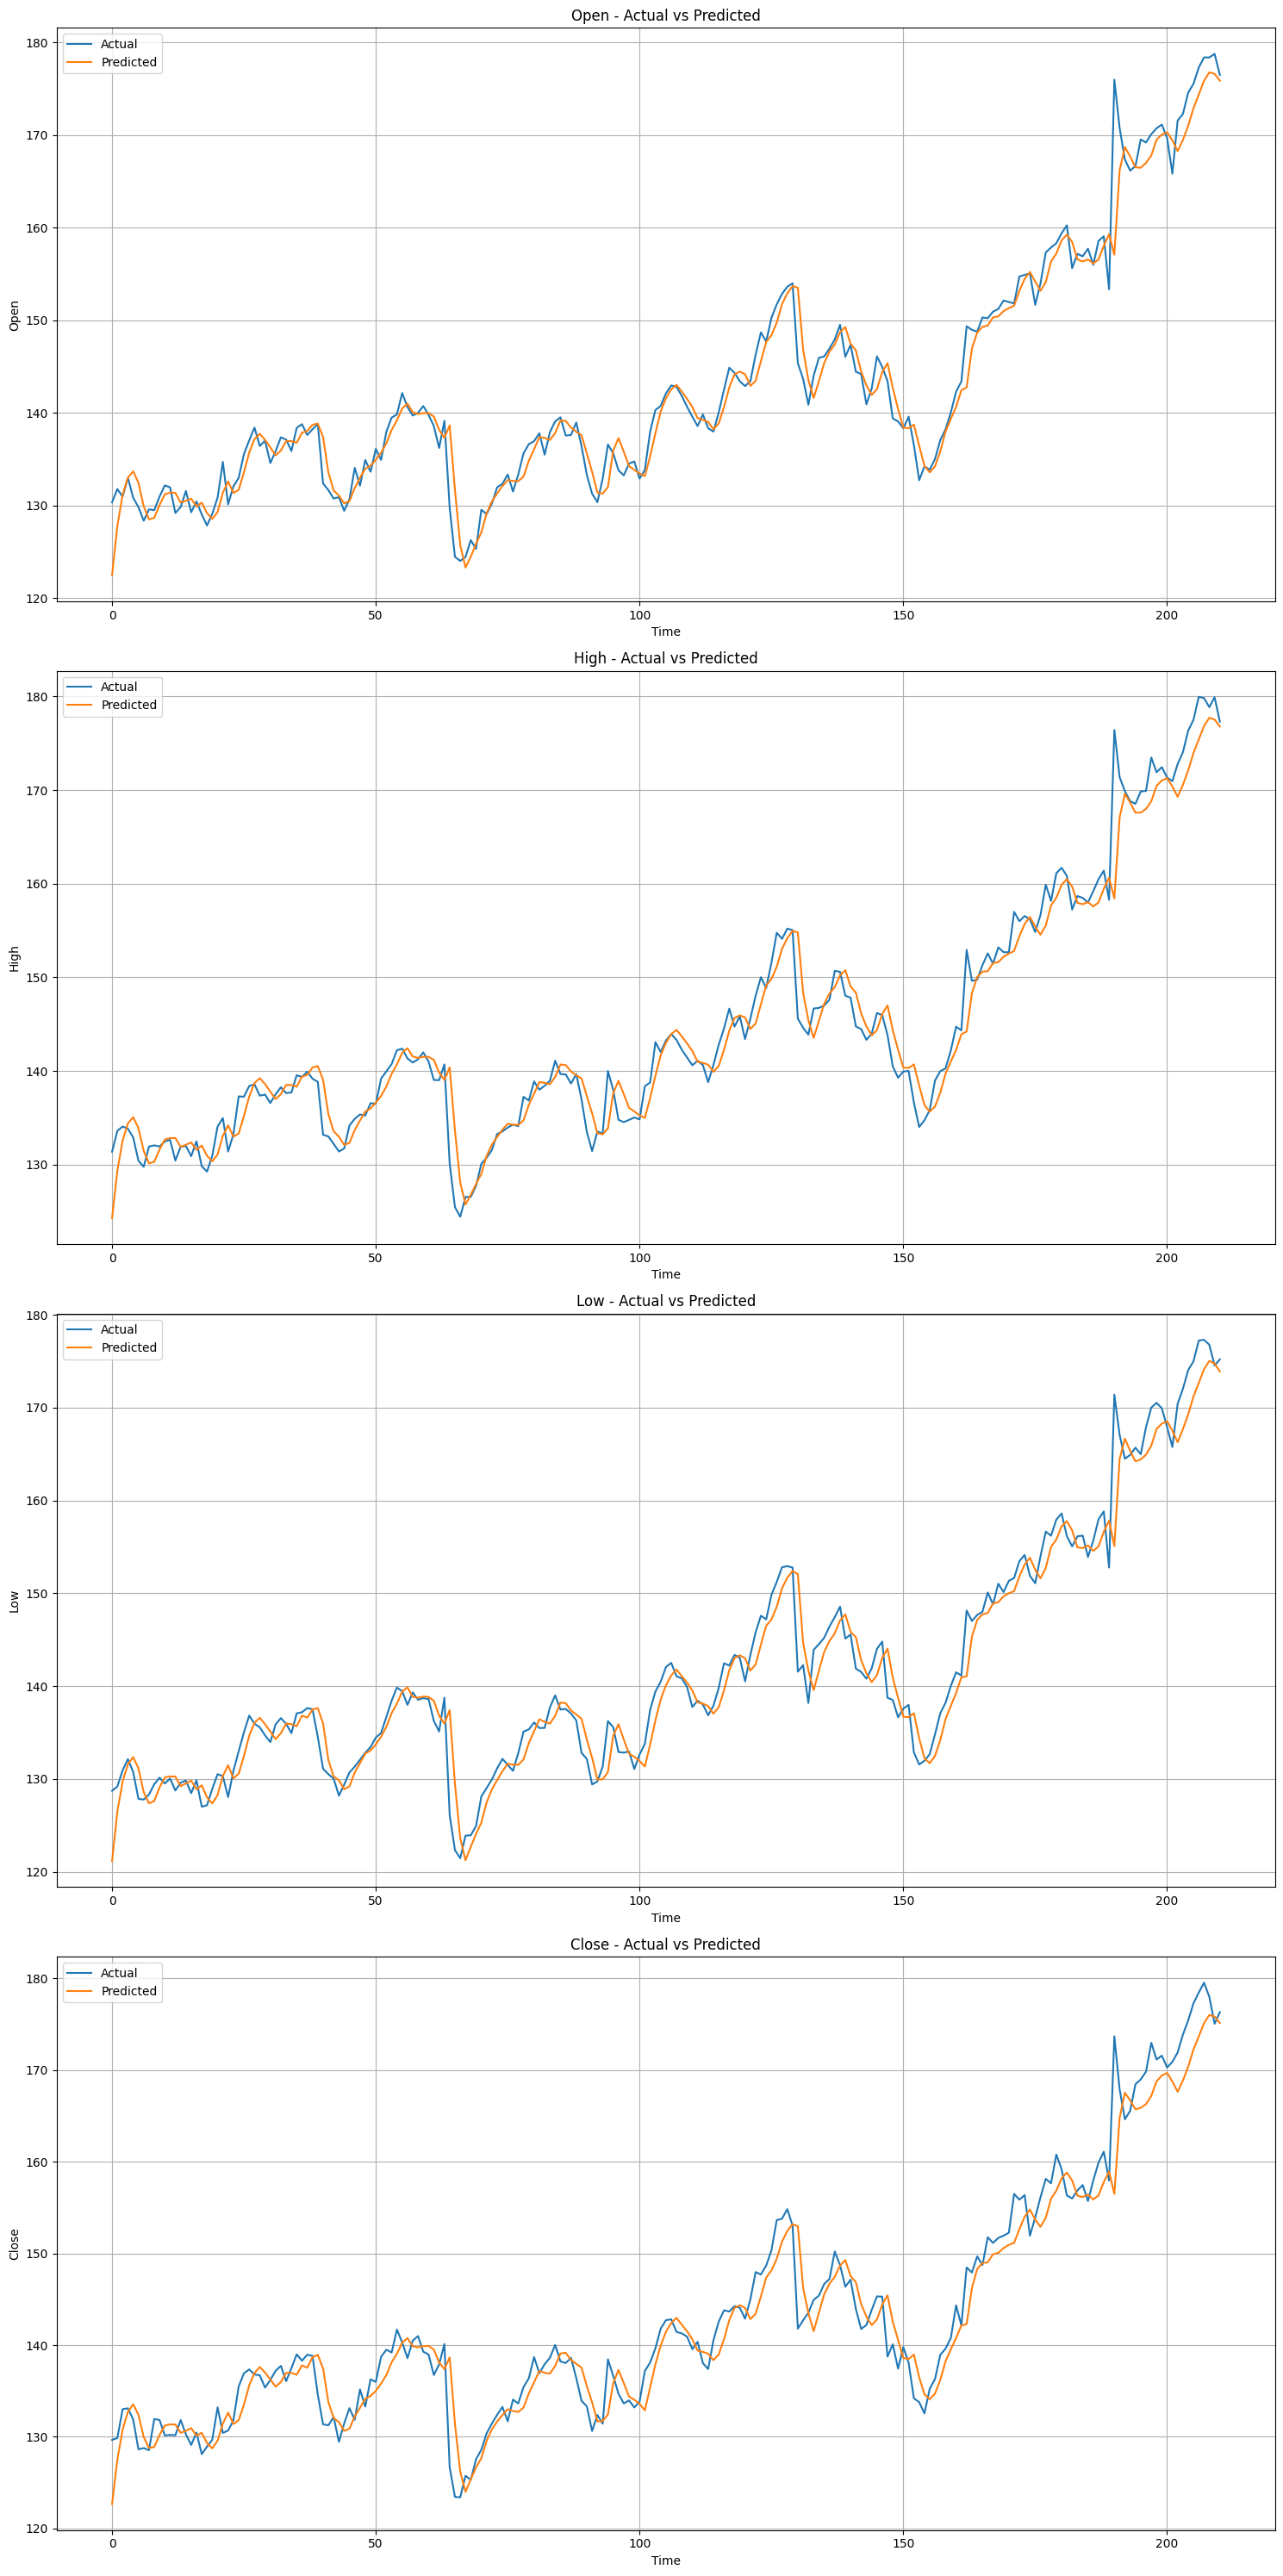

In [68]:
features = ['open', 'high', 'low', 'volume', 'close', '10d_SMA', '15d_SMA']
target_features = ['open', 'high', 'low', 'close']
seq_len = 15

X_train, y_train, X_val, y_val, X_test, y_test, scaler = preprocess_data(df, features, target_features, seq_len)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

model = train_lstm_model(train_loader, val_loader, num_features=len(features), output_size=len(target_features))

predict_and_plot(model, X_test, y_test, scaler, target_features, features)


In [69]:
last_sequence = X_test[-1]  # shape: (seq_len, num_features)
forecast = forecast_next_days(model, last_sequence, scaler, features, target_features, days=10)
print(pd.DataFrame(forecast))

         open        high         low       close
0  175.885935  176.786495  173.893967  175.141559
1  168.993207  169.990671  167.800703  167.183528
2  161.427479  162.953263  161.149499  159.544809
3  154.132209  156.223095  154.514943  152.684454
4  147.450384  149.977113  148.163558  146.509068
5  141.468128  144.270488  142.244322  140.978325
6  136.195924  139.131352  136.848793  136.069516
7  131.611473  134.567916  132.022079  131.758102
8  127.672794  130.571179  127.774838  128.010636
9  124.324230  127.115820  124.091690  124.784210
